# FloodFu-Net: Cross-Sensor Spectral-Spatial Fusion Network for Flood Extent Segmentation

**Dataset used** — **Sen1Floods11** (Cloud to Street / Radiant Earth), a public hand-labeled flood benchmark.
- 4,831 co-registered chips (512 × 512 at ~10 m) from 11 flood events across 6 continents.
- Each chip has: Sentinel-1 GRD `[VV, VH]`, Sentinel-2 L1C `[B1..B12]`, and a manually labeled water mask.
- Public bucket: `https://storage.googleapis.com/sen1floods11/` — no authentication, no API key.

**Pipeline stages** (each stage writes a checkpoint to Drive; on reconnect the notebook resumes at the next unfinished stage):

| Stage | Output | Checkpoint |
|-------|--------|------------|
| 1 | Env + Drive | `stage1_env.ok` |
| 2 | Sen1Floods11 chips downloaded to Drive | `stage2_download.ok` |
| 3 | Multi-index tensors (NDWI, MNDWI, AWEI, VV/VH) | `stage3_indices.ok` |
| 4 | Train / val / test patch arrays | `stage4_patches.ok` |
| 5 | FloodFu-Net weights (best + latest) | `stage5_floodfunet_*.pt` |
| 6 | Segmentation metrics | `stage6_metrics.json` |
| 7 | Predicted flood maps on test chips | `stage7_maps.npz` |
| 8 | Six baselines (Otsu, NDWI, RF, U-Net×3) + curves | `stage8_all_results.json` |
| 9 | Ablation (no cross-gate) | `ablate_*.pt` |
| 10 | Per-event, boundary quality, efficiency, qualitative grid, failure cases | `stage10_*.json/csv` |
| 11 | Publication-quality composite figure | `stage11_composite.{png,pdf}` |
| 12 | Reproducibility manifest | `run_manifest.json` |

**Highlights**
- Seven-method comparison (thresholding, classical ML, three U-Nets, no-gate ablation, proposed).
- Nine metrics per method (IoU, F1, Precision, Recall, MCC, Kappa, Accuracy, ROC-AUC, PR-AUC) plus boundary quality (HD95, BF1@2 px).
- ROC + PR + radar + head-to-head bar + per-event heat map + ablation waterfall + efficiency scatter + qualitative grid + failure gallery + one composite figure ready for a manuscript.


## Stage 1 — Environment and Drive

In [ ]:
import subprocess, sys, importlib
def _pip(pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', '-q', 'install', *pkgs])

required = {
    'rasterio': 'rasterio',
    'requests': 'requests',
    'torch': 'torch',
    'scikit-learn': 'sklearn',
    'scikit-image': 'skimage',
    'seaborn': 'seaborn',
    'plotly': 'plotly',
    'tqdm': 'tqdm',
    'pandas': 'pandas',
}
missing = [p for p, m in required.items() if importlib.util.find_spec(m) is None]
if missing:
    _pip(missing)
print('Packages ready:', ', '.join(required))

Packages ready: rasterio, requests, torch, scikit-learn, scikit-image, seaborn, plotly, tqdm, pandas


In [ ]:
import os, json, math, time, datetime as dt
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    ROOT = Path('/content/drive/MyDrive/FloodFuNet')
else:
    ROOT = Path.home() / 'FloodFuNet'

DIRS = {k: ROOT / k for k in
        ['raw_s1', 'raw_s2', 'raw_label', 'indices',
         'patches', 'checkpoints', 'figures', 'maps']}
for d in [ROOT, *DIRS.values()]:
    d.mkdir(parents=True, exist_ok=True)
CKPT = ROOT / 'checkpoints'

print('Project root :', ROOT)
for k, v in DIRS.items():
    print(f'  {k:12s} -> {v}')
(CKPT / 'stage1_env.ok').write_text(dt.datetime.utcnow().isoformat())

Mounted at /content/drive
Project root : /content/drive/MyDrive/FloodFuNet
  raw_s1       -> /content/drive/MyDrive/FloodFuNet/raw_s1
  raw_s2       -> /content/drive/MyDrive/FloodFuNet/raw_s2
  raw_label    -> /content/drive/MyDrive/FloodFuNet/raw_label
  indices      -> /content/drive/MyDrive/FloodFuNet/indices
  patches      -> /content/drive/MyDrive/FloodFuNet/patches
  checkpoints  -> /content/drive/MyDrive/FloodFuNet/checkpoints
  figures      -> /content/drive/MyDrive/FloodFuNet/figures
  maps         -> /content/drive/MyDrive/FloodFuNet/maps


/tmp/ipykernel_525/2512308606.py:22: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  (CKPT / 'stage1_env.ok').write_text(dt.datetime.utcnow().isoformat())


26

In [ ]:
import matplotlib.pyplot as plt, matplotlib as mpl, seaborn as sns
sns.set_theme(style='whitegrid', context='talk')
mpl.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#333', 'axes.titleweight': 'bold',
    'grid.color': '#dddddd', 'grid.linestyle': '--', 'grid.alpha': 0.6,
})

## Stage 2 — Fetch Sen1Floods11 chips from the public bucket

Files are pulled once and cached on Drive. Re-runs skip anything already on disk.

In [ ]:
import requests, pandas as pd
from tqdm.auto import tqdm

BASE  = 'https://storage.googleapis.com/sen1floods11/v1.1'
SPLIT = f'{BASE}/splits/flood_handlabeled'
DATA  = f'{BASE}/data/flood_events/HandLabeled'

SPLITS = {
    'train': 'flood_train_data.csv',
    'val'  : 'flood_valid_data.csv',
    'test' : 'flood_test_data.csv',
}

STAGE2_OK = CKPT / 'stage2_download.ok'

# ----------------------------------------------------------------------
# Cap so first-time download stays under ~2 GB. Raise for the full dataset.
MAX_PER_SPLIT = {'train': 300, 'val': 60, 'test': 60}
# ----------------------------------------------------------------------

def fetch(url, dest, retries=3):
    if dest.exists() and dest.stat().st_size > 0:
        return True
    for k in range(retries):
        try:
            r = requests.get(url, timeout=60, stream=True)
            if r.status_code == 200:
                tmp = dest.with_suffix(dest.suffix + '.part')
                with open(tmp, 'wb') as f:
                    for c in r.iter_content(1 << 15):
                        if c: f.write(c)
                tmp.rename(dest)
                return True
        except Exception:
            time.sleep(2 * (k + 1))
    return False

def read_split(name):
    csv_url = f'{SPLIT}/{SPLITS[name]}'
    csv_local = DIRS['raw_s1'] / SPLITS[name]
    fetch(csv_url, csv_local)
    df = pd.read_csv(csv_local, header=None, names=['s1', 'label'])
    return df

def download_split(name, cap):
    df = read_split(name)
    df = df.head(cap).reset_index(drop=True)
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f'{name}'):
        s1 = row['s1']
        lb = row['label']
        s2 = s1.replace('S1Hand', 'S2Hand')
        fetch(f'{DATA}/S1Hand/{s1}',      DIRS['raw_s1']    / s1)
        fetch(f'{DATA}/S2Hand/{s2}',      DIRS['raw_s2']    / s2)
        fetch(f'{DATA}/LabelHand/{lb}',   DIRS['raw_label'] / lb)
    return df

if STAGE2_OK.exists():
    splits = {k: read_split(k).head(MAX_PER_SPLIT[k]) for k in SPLITS}
    print('Stage 2 resumed. Chip counts:', {k: len(v) for k, v in splits.items()})
else:
    splits = {k: download_split(k, MAX_PER_SPLIT[k]) for k in SPLITS}
    STAGE2_OK.write_text(json.dumps({k: len(v) for k, v in splits.items()}))
    print('Stage 2 complete. Chip counts:', {k: len(v) for k, v in splits.items()})

Stage 2 resumed. Chip counts: {'train': 252, 'val': 60, 'test': 60}


Showcase chip : Ghana_141910_S1Hand.tif   flood fraction : 27.0%


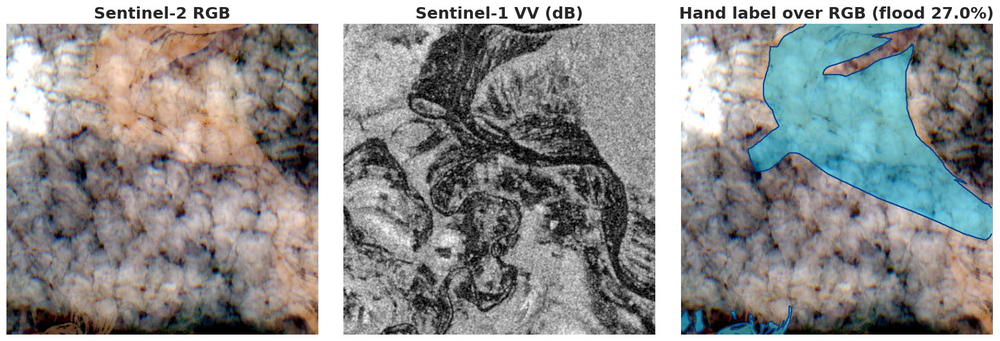

In [ ]:
import numpy as np, rasterio
from matplotlib.colors import ListedColormap

def read_tif(path, bands=None):
    with rasterio.open(path) as src:
        arr = src.read() if bands is None else src.read(bands)
    return arr

def stretch_ch(a, p=(2, 98)):
    a = a.astype('float32')
    lo, hi = np.nanpercentile(a, p)
    return np.clip((a - lo) / max(hi - lo, 1e-6), 0, 1)

def make_rgb(s2, p=(2, 98), gamma=0.85):
    # per-channel percentile stretch keeps clouds and haze from washing out RGB
    r = stretch_ch(s2[3], p)
    g = stretch_ch(s2[2], p)
    b = stretch_ch(s2[1], p)
    return np.power(np.stack([r, g, b], axis=-1), gamma)

def pick_showcase(df, min_flood=0.08, max_flood=0.60, scan_limit=80):
    best, best_frac = None, -1.0
    for _, row in df.head(scan_limit).iterrows():
        lp = DIRS['raw_label'] / row['label']
        if not lp.exists(): continue
        lab = read_tif(lp)[0]
        frac = float((lab == 1).mean())
        if min_flood <= frac <= max_flood:
            return row, lab, frac
        if frac > best_frac:
            best, best_frac = (row, lab), frac
    return best[0], best[1], best_frac

sample, lb, frac = pick_showcase(splits['train'])
s1  = read_tif(DIRS['raw_s1'] / sample['s1'])
s2  = read_tif(DIRS['raw_s2'] / sample['s1'].replace('S1Hand', 'S2Hand'))
rgb = make_rgb(s2)
print(f'Showcase chip : {sample["s1"]}   flood fraction : {frac:.1%}')

fig, ax = plt.subplots(1, 3, figsize=(16, 5.4))
ax[0].imshow(rgb); ax[0].set_title('Sentinel-2 RGB'); ax[0].axis('off')

ax[1].imshow(s1[0], cmap='gray', vmin=-25, vmax=0)
ax[1].set_title('Sentinel-1 VV (dB)'); ax[1].axis('off')

ax[2].imshow(rgb)
ax[2].imshow(np.ma.masked_where(lb != 1, lb),
             cmap=ListedColormap(['#00d0ff']), alpha=0.45)
ax[2].contour(lb == 1, colors=['#023e8a'], linewidths=1.4)
ax[2].set_title(f'Hand label over RGB (flood {frac:.1%})'); ax[2].axis('off')

plt.tight_layout()
plt.savefig(DIRS['figures'] / 'stage2_quicklook.png', dpi=160, bbox_inches='tight')
plt.show()

## Stage 3 — Multi-index tensor

Per chip: 4 SAR channels + 6 optical channels.

$\text{NDWI}  = \frac{G - N}{G + N}$,
$\text{MNDWI} = \frac{G - S}{G + S}$,
$\text{AWEI}  = 4(G - S) - (0.25 N + 2.75 S)$,
$\text{VV-VH} = \text{VV} - \text{VH}$,
$\text{VV+VH} = \text{VV} + \text{VH}$.

In [ ]:
STAGE3_OK = CKPT / 'stage3_indices.ok'
IDX_DIR   = DIRS['indices']

CHANNEL_NAMES = ['VV', 'VH', 'VV-VH', 'VV+VH',
                 'NDWI', 'MNDWI', 'AWEI',
                 'B_red', 'B_NIR', 'B_SWIR']

SAR_IDX = [0, 1, 2, 3]
OPT_IDX = [4, 5, 6, 7, 8, 9]

def build_tensor(s1_path, s2_path):
    s1 = read_tif(s1_path).astype('float32')                          # (2, H, W)
    s2 = read_tif(s2_path).astype('float32') / 10000.0                # (13, H, W)
    VV, VH = s1[0], s1[1]
    # Sen1Floods11 S2Hand bands are B1..B12, so B2=Blue idx 1, B3=Green idx 2, B4=Red idx 3, B8=NIR idx 7, B11=SWIR idx 10
    G, R, N, S = s2[2], s2[3], s2[7], s2[10]
    eps = 1e-6
    NDWI  = (G - N) / (G + N + eps)
    MNDWI = (G - S) / (G + S + eps)
    AWEI  = 4 * (G - S) - (0.25 * N + 2.75 * S)
    stack = np.stack([VV, VH, VV - VH, VV + VH,
                      NDWI, MNDWI, AWEI, R, N, S], axis=0).astype('float32')
    return stack   # (10, H, W)

def index_path(name):
    return IDX_DIR / (name.replace('.tif', '.npy'))

if STAGE3_OK.exists():
    print('Stage 3 resumed from checkpoint.')
else:
    for split_name, df in splits.items():
        for _, row in tqdm(df.iterrows(), total=len(df), desc=f'idx {split_name}'):
            out = index_path(row['s1'])
            if out.exists(): continue
            s1p = DIRS['raw_s1'] / row['s1']
            s2p = DIRS['raw_s2'] / row['s1'].replace('S1Hand', 'S2Hand')
            if not (s1p.exists() and s2p.exists()): continue
            arr = build_tensor(s1p, s2p)
            np.save(out, np.nan_to_num(arr, nan=0.0))
    STAGE3_OK.write_text('ok')
    print('Stage 3 complete.')

Stage 3 resumed from checkpoint.


Tensor shape: (10, 512, 512) -> ['VV', 'VH', 'VV-VH', 'VV+VH', 'NDWI', 'MNDWI', 'AWEI', 'B_red', 'B_NIR', 'B_SWIR']


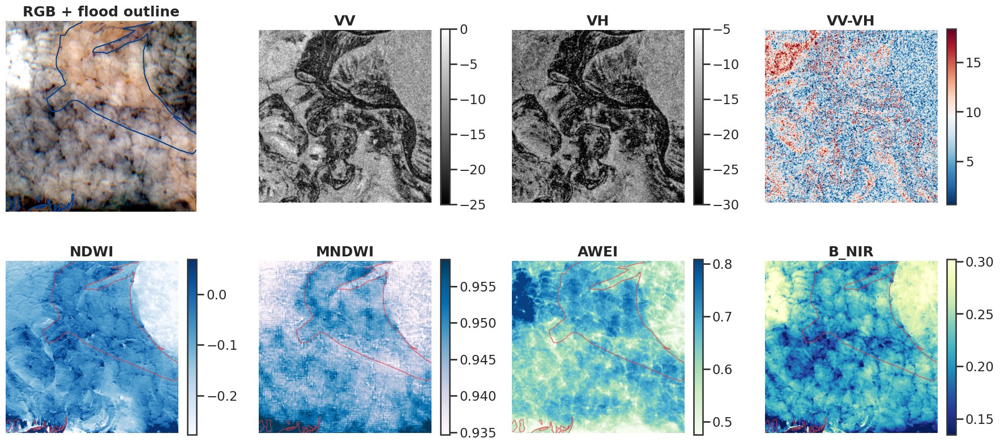

In [ ]:
# Water indices go dry -> wet (sequential), not neg -> pos (diverging), so a
# percentile-stretched sequential cmap keeps contrast even on hazy chips.
sample_arr = np.load(index_path(sample['s1']))
print('Tensor shape:', sample_arr.shape, '->', CHANNEL_NAMES)

fig = plt.figure(figsize=(18, 8.5))
gs  = fig.add_gridspec(2, 4, height_ratios=[1.0, 1.0])

ax0 = fig.add_subplot(gs[0, 0])
ax0.imshow(rgb)
ax0.contour(lb == 1, colors=['#023e8a'], linewidths=1.4)
ax0.set_title('RGB + flood outline'); ax0.axis('off')

# Top row: three SAR channels
top_sar = [('VV', 'gray', (-25, 0)),
           ('VH', 'gray', (-30, -5)),
           ('VV-VH', 'RdBu_r', None)]
for k, (n, cm, vr) in enumerate(top_sar):
    ax = fig.add_subplot(gs[0, k + 1])
    m = sample_arr[CHANNEL_NAMES.index(n)]
    if vr is None:
        vr = tuple(np.nanpercentile(m, (2, 98)))
    im = ax.imshow(m, cmap=cm, vmin=vr[0], vmax=vr[1])
    ax.set_title(n); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

# Bottom row: water indices with sequential cmaps + robust percentile stretch
bottom = [('NDWI', 'Blues'), ('MNDWI', 'PuBu'), ('AWEI', 'GnBu'), ('B_NIR', 'YlGnBu_r')]
for k, (n, cm) in enumerate(bottom):
    ax = fig.add_subplot(gs[1, k])
    m = sample_arr[CHANNEL_NAMES.index(n)]
    lo, hi = np.nanpercentile(m, (2, 98))
    if hi - lo < 1e-4:                # fully saturated chip, force a nominal range
        lo, hi = float(np.nanmin(m)), float(np.nanmax(m) + 1e-3)
    im = ax.imshow(m, cmap=cm, vmin=lo, vmax=hi)
    ax.contour(lb == 1, colors=['#e63946'], linewidths=1.0, alpha=0.7)
    ax.set_title(n); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig(DIRS['figures'] / 'stage3_indices.png', dpi=160, bbox_inches='tight')
plt.show()

## Stage 4 — Patch arrays for training

Each 512 × 512 chip is tiled into 128 × 128 patches. Pixels labeled −1 (unknown) become 0 for training but are masked out of the loss.

In [ ]:
STAGE4_OK = CKPT / 'stage4_patches.ok'
P = 128
STRIDE = 128

def tile_chip(feat, lab, p=P, s=STRIDE):
    H, W = feat.shape[1], feat.shape[2]
    xs, ys, vs = [], [], []
    for i in range(0, H - p + 1, s):
        for j in range(0, W - p + 1, s):
            f = feat[:, i:i+p, j:j+p]
            l = lab[i:i+p, j:j+p]
            valid = (l != -1).astype('uint8')
            if valid.mean() < 0.30: continue
            xs.append(f.astype('float32'))
            ys.append(np.where(l == 1, 1, 0).astype('uint8'))
            vs.append(valid)
    return xs, ys, vs

def build_split(df):
    Xs, Ys, Vs = [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='patches'):
        ip = index_path(row['s1'])
        lp = DIRS['raw_label'] / row['label']
        if not (ip.exists() and lp.exists()): continue
        feat = np.load(ip)
        lab  = read_tif(lp)[0]
        xs, ys, vs = tile_chip(feat, lab)
        Xs.extend(xs); Ys.extend(ys); Vs.extend(vs)
    return (np.stack(Xs) if Xs else np.zeros((0, 10, P, P), dtype='float32'),
            np.stack(Ys) if Ys else np.zeros((0, P, P), dtype='uint8'),
            np.stack(Vs) if Vs else np.zeros((0, P, P), dtype='uint8'))

cache = DIRS['patches'] / 'patches.npz'
if STAGE4_OK.exists() and cache.exists():
    d = np.load(cache)
    Xtr, Ytr, Vtr = d['Xtr'], d['Ytr'], d['Vtr']
    Xva, Yva, Vva = d['Xva'], d['Yva'], d['Vva']
    Xte, Yte, Vte = d['Xte'], d['Yte'], d['Vte']
    print('Stage 4 resumed. Shapes:', Xtr.shape, Xva.shape, Xte.shape)
else:
    Xtr, Ytr, Vtr = build_split(splits['train'])
    Xva, Yva, Vva = build_split(splits['val'])
    Xte, Yte, Vte = build_split(splits['test'])
    np.savez(cache,
             Xtr=Xtr, Ytr=Ytr, Vtr=Vtr,
             Xva=Xva, Yva=Yva, Vva=Vva,
             Xte=Xte, Yte=Yte, Vte=Vte)
    STAGE4_OK.write_text('ok')
    print('Stage 4 complete. Shapes:', Xtr.shape, Xva.shape, Xte.shape)

Stage 4 resumed. Shapes: (3711, 10, 128, 128) (848, 10, 128, 128) (858, 10, 128, 128)


/tmp/ipykernel_525/1585384915.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['train', 'val', 'test'], y=counts, palette='crest', ax=ax1)


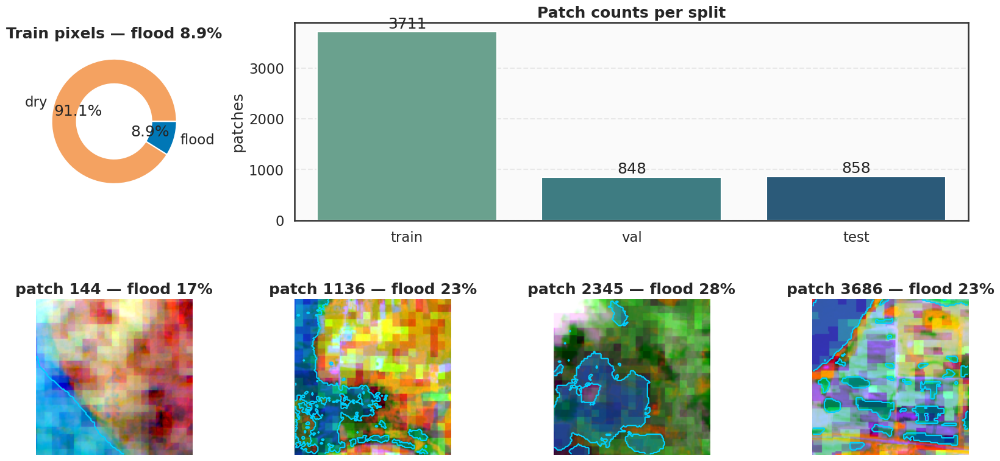

In [ ]:
from matplotlib.colors import ListedColormap

flood_frac = 100.0 * Ytr.mean()
fig = plt.figure(figsize=(16, 8.5))
gs  = fig.add_gridspec(2, 4, height_ratios=[1.0, 1.15])

# --- top left: pixel class balance
ax0 = fig.add_subplot(gs[0, 0])
ax0.pie([100.0 - flood_frac, flood_frac],
        labels=['dry', 'flood'],
        colors=['#f4a261', '#0077b6'],
        autopct='%1.1f%%',
        wedgeprops=dict(width=0.4, edgecolor='white'))
ax0.set_title(f'Train pixels — flood {flood_frac:.1f}%')

# --- top right: patch counts
ax1 = fig.add_subplot(gs[0, 1:])
counts = [len(Xtr), len(Xva), len(Xte)]
sns.barplot(x=['train', 'val', 'test'], y=counts, palette='crest', ax=ax1)
for i, v in enumerate(counts):
    ax1.text(i, v + max(counts) * 0.02, str(v), ha='center')
ax1.set_title('Patch counts per split'); ax1.set_ylabel('patches')

# --- bottom row: MIXED-flood patches (10-70%) with clear water boundary.
#     Solid-cyan overlays disappear when the whole patch is water,
#     so use a false-colour NIR / SWIR / Red backdrop and outline the flood.
mean_flood = Ytr.mean(axis=(1, 2))
mixed = np.where((mean_flood > 0.10) & (mean_flood < 0.70))[0]
if len(mixed) < 4:
    mixed = np.argsort(-mean_flood)[:4]
picks = mixed[np.linspace(0, len(mixed) - 1, 4).astype(int)]

def patch_falsecolor(x):
    # NIR (B_NIR), SWIR (B_SWIR), Red (B_red) — water shows up dark blue,
    # vegetation red, bare soil beige. Sharp water outlines against land.
    r = stretch_ch(x[CHANNEL_NAMES.index('B_NIR')])
    g = stretch_ch(x[CHANNEL_NAMES.index('B_SWIR')])
    b = stretch_ch(x[CHANNEL_NAMES.index('B_red')])
    return np.stack([r, g, b], axis=-1)

for k, idx in enumerate(picks):
    a = fig.add_subplot(gs[1, k])
    a.imshow(patch_falsecolor(Xtr[idx]))
    a.contour(Ytr[idx] == 1, colors=['#00d0ff'], linewidths=1.6)
    a.imshow(np.ma.masked_where(Ytr[idx] == 0, Ytr[idx]),
             cmap=ListedColormap(['#00d0ff']), alpha=0.25)
    a.set_title(f'patch {idx} — flood {100*Ytr[idx].mean():.0f}%')
    a.axis('off')

plt.tight_layout()
plt.savefig(DIRS['figures'] / 'stage4_dataset.png', dpi=160, bbox_inches='tight')
plt.show()

## Stage 5 — FloodFu-Net architecture

SAR branch and optical branch each run through a 3-scale encoder. At every U-Net skip a **cross-sensor gate** blends them. The decoder returns a per-pixel logit. Under 2 M parameters.

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device, torch.cuda.get_device_name(0) if device.type == 'cuda' else '')

class ConvBlock(nn.Module):
    def __init__(self, ci, co):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.GELU(),
            nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.GELU())
    def forward(self, x): return self.net(x)

class Encoder(nn.Module):
    def __init__(self, ci, w=(32, 64, 128)):
        super().__init__()
        self.b1, self.b2, self.b3 = ConvBlock(ci, w[0]), ConvBlock(w[0], w[1]), ConvBlock(w[1], w[2])
        self.p = nn.MaxPool2d(2)
    def forward(self, x):
        f1 = self.b1(x); f2 = self.b2(self.p(f1)); f3 = self.b3(self.p(f2))
        return f1, f2, f3

class CrossGate(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.q = nn.Conv2d(c, c, 1)
        self.k = nn.Conv2d(c, c, 1)
        self.g = nn.Sequential(nn.Conv2d(2 * c, c, 1), nn.Sigmoid())
    def forward(self, a, b):
        attn = torch.sigmoid((self.q(a) * self.k(b)).mean(1, keepdim=True))
        gate = self.g(torch.cat([a * attn, b * (1 - attn)], dim=1))
        return gate * a + (1 - gate) * b

class Decoder(nn.Module):
    def __init__(self, w=(32, 64, 128)):
        super().__init__()
        self.u2 = nn.ConvTranspose2d(w[2], w[1], 2, stride=2)
        self.d2 = ConvBlock(w[1] * 2, w[1])
        self.u1 = nn.ConvTranspose2d(w[1], w[0], 2, stride=2)
        self.d1 = ConvBlock(w[0] * 2, w[0])
        self.out = nn.Conv2d(w[0], 1, 1)
    def forward(self, f1, f2, f3):
        x = self.u2(f3); x = self.d2(torch.cat([x, f2], 1))
        x = self.u1(x);  x = self.d1(torch.cat([x, f1], 1))
        return self.out(x)

class FloodFuNet(nn.Module):
    def __init__(self, sar_c, opt_c):
        super().__init__()
        w = (32, 64, 128)
        self.sar = Encoder(sar_c, w)
        self.opt = Encoder(opt_c, w)
        self.g1, self.g2, self.g3 = CrossGate(w[0]), CrossGate(w[1]), CrossGate(w[2])
        self.dec = Decoder(w)
    def forward(self, xs, xo):
        s1, s2, s3 = self.sar(xs)
        o1, o2, o3 = self.opt(xo)
        return self.dec(self.g1(s1, o1), self.g2(s2, o2), self.g3(s3, o3))

model = FloodFuNet(len(SAR_IDX), len(OPT_IDX)).to(device)
print('Parameters (M):', sum(p.numel() for p in model.parameters()) / 1e6)

Device: cuda Tesla T4
Parameters (M): 0.843553


In [ ]:
class FloodDS(Dataset):
    def __init__(self, X, Y, V):
        self.X, self.Y, self.V = X, Y, V
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        x = self.X[i]                                               # (C, H, W)
        xs = x[SAR_IDX]; xo = x[OPT_IDX]
        return (torch.from_numpy(xs).float(),
                torch.from_numpy(xo).float(),
                torch.from_numpy(self.Y[i]).float().unsqueeze(0),
                torch.from_numpy(self.V[i]).float().unsqueeze(0))

BS = 16
train_loader = DataLoader(FloodDS(Xtr, Ytr, Vtr), batch_size=BS, shuffle=True)
val_loader   = DataLoader(FloodDS(Xva, Yva, Vva), batch_size=BS)
test_loader  = DataLoader(FloodDS(Xte, Yte, Vte), batch_size=BS)
print(f'Batches: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}')

Batches: train=232, val=53, test=54


### Training with per-epoch checkpointing

Best and latest weights land on Drive after each epoch. A disconnect resumes from the last completed epoch.

In [ ]:
EPOCHS, LR, WD = 30, 1e-3, 1e-4
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
bce = nn.BCEWithLogitsLoss(reduction='none')

def masked_bce(logits, y, m):
    l = bce(logits, y) * m
    return l.sum() / m.sum().clamp_min(1.0)

def masked_dice(logits, y, m, eps=1e-6):
    p = torch.sigmoid(logits) * m
    yy = y * m
    inter = (p * yy).sum(dim=(1, 2, 3))
    denom = p.sum(dim=(1, 2, 3)) + yy.sum(dim=(1, 2, 3))
    return 1 - ((2 * inter + eps) / (denom + eps)).mean()

def iou_batch(logits, y, m, thr=0.5, eps=1e-6):
    p = ((torch.sigmoid(logits) > thr).float()) * m
    yy = y * m
    inter = (p * yy).sum(dim=(1, 2, 3))
    union = ((p + yy) >= 1).float().sum(dim=(1, 2, 3))
    return ((inter + eps) / (union + eps)).mean().item()

BEST   = CKPT / 'stage5_floodfunet_best.pt'
LATEST = CKPT / 'stage5_floodfunet_latest.pt'
HIST   = CKPT / 'stage5_history.json'

start_epoch, best_iou = 0, 0.0
history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}
if LATEST.exists():
    ck = torch.load(LATEST, map_location=device)
    model.load_state_dict(ck['model'])
    opt.load_state_dict(ck['opt'])
    sch.load_state_dict(ck['sch'])
    start_epoch, best_iou, history = ck['epoch'] + 1, ck['best_iou'], ck['history']
    print(f'Resuming from epoch {start_epoch}, best IoU {best_iou:.4f}')

def run_epoch(loader, train):
    model.train(train)
    tot, tl, ti = 0, 0.0, 0.0
    for xs, xo, y, m in loader:
        xs, xo, y, m = xs.to(device), xo.to(device), y.to(device), m.to(device)
        logits = model(xs, xo)
        loss = 0.5 * masked_bce(logits, y, m) + 0.5 * masked_dice(logits, y, m)
        if train:
            opt.zero_grad(); loss.backward(); opt.step()
        bs = xs.size(0)
        tl += loss.item() * bs
        ti += iou_batch(logits.detach(), y, m) * bs
        tot += bs
    return tl / tot, ti / tot

for ep in range(start_epoch, EPOCHS):
    tl, ti = run_epoch(train_loader, True)
    with torch.no_grad():
        vl, vi = run_epoch(val_loader, False)
    sch.step()
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_iou'].append(ti);  history['val_iou'].append(vi)
    if vi > best_iou:
        best_iou = vi
        torch.save({'model': model.state_dict(), 'val_iou': vi}, BEST)
    torch.save({'model': model.state_dict(), 'opt': opt.state_dict(),
                'sch': sch.state_dict(), 'epoch': ep,
                'best_iou': best_iou, 'history': history}, LATEST)
    HIST.write_text(json.dumps(history))
    print(f'Ep {ep+1:02d}/{EPOCHS}  train {tl:.3f}/{ti:.3f}  val {vl:.3f}/{vi:.3f}  best {best_iou:.3f}')
print('Stage 5 complete. Best val IoU:', best_iou)

Resuming from epoch 30, best IoU 0.6637
Stage 5 complete. Best val IoU: 0.6636727435408898


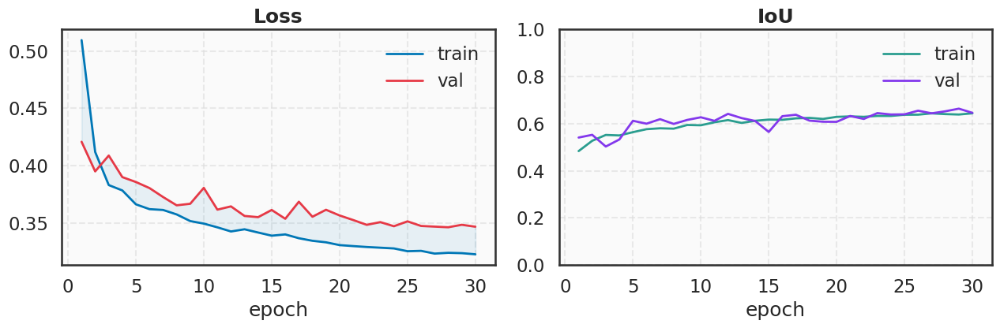

In [ ]:
hs = json.loads(HIST.read_text())
ep = np.arange(1, len(hs['train_loss']) + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ep, hs['train_loss'], label='train', color='#0077b6', linewidth=2)
ax[0].plot(ep, hs['val_loss'],   label='val',   color='#e63946', linewidth=2)
ax[0].fill_between(ep, hs['train_loss'], hs['val_loss'], color='#0077b6', alpha=0.08)
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend(frameon=False)
ax[1].plot(ep, hs['train_iou'], label='train', color='#2a9d8f', linewidth=2)
ax[1].plot(ep, hs['val_iou'],   label='val',   color='#8338ec', linewidth=2)
ax[1].set_ylim(0, 1); ax[1].set_title('IoU'); ax[1].set_xlabel('epoch'); ax[1].legend(frameon=False)
plt.tight_layout()
plt.savefig(DIRS['figures'] / 'stage5_training.png', dpi=150, bbox_inches='tight')
plt.show()

## Stage 6 — Held-out evaluation

In [ ]:
from sklearn.metrics import (confusion_matrix, f1_score,
                             precision_score, recall_score,
                             jaccard_score, matthews_corrcoef)
STAGE6_OK = CKPT / 'stage6_metrics.json'
model.load_state_dict(torch.load(BEST, map_location=device)['model'])
model.eval()

yp, yt = [], []
preds_store = []
with torch.no_grad():
    for xs, xo, y, m in test_loader:
        p = torch.sigmoid(model(xs.to(device), xo.to(device))).cpu().numpy()
        preds_store.append(p[:, 0])
        mask = m.numpy()[:, 0].astype(bool)
        yp.append((p[:, 0][mask] > 0.5).astype('uint8'))
        yt.append(y.numpy()[:, 0][mask].astype('uint8'))
preds_store = np.concatenate(preds_store)
yp = np.concatenate(yp); yt = np.concatenate(yt)

metrics = {
    'iou_flood'   : float(jaccard_score(yt, yp, pos_label=1)),
    'f1_flood'    : float(f1_score(yt, yp, pos_label=1)),
    'precision'   : float(precision_score(yt, yp, pos_label=1)),
    'recall'      : float(recall_score(yt, yp, pos_label=1)),
    'mcc'         : float(matthews_corrcoef(yt, yp)),
    'overall_acc' : float((yt == yp).mean()),
}
STAGE6_OK.write_text(json.dumps(metrics, indent=2))
for k, v in metrics.items():
    print(f'  {k:12s} {v:.4f}')

  iou_flood    0.7861
  f1_flood     0.8803
  precision    0.8953
  recall       0.8657
  mcc          0.8633
  overall_acc  0.9700


/tmp/ipykernel_525/3122142282.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




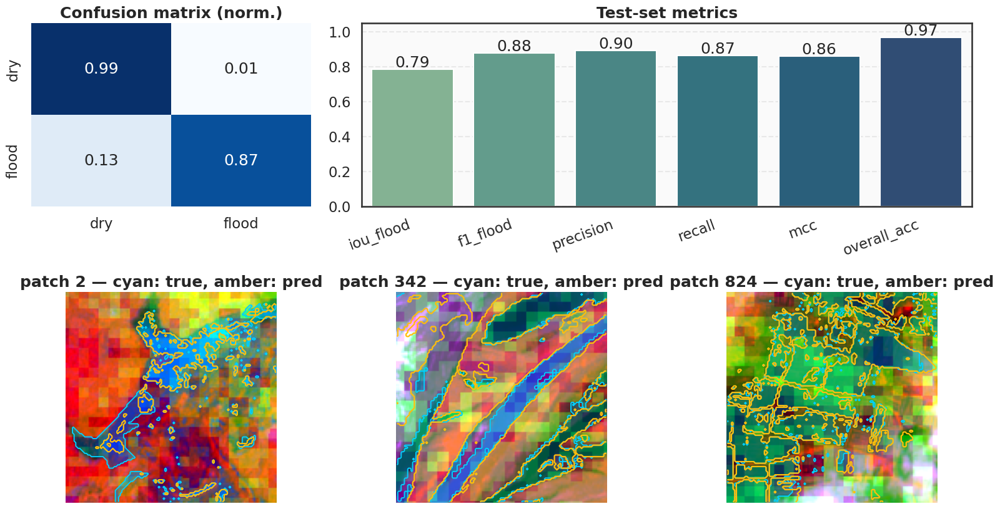

In [ ]:
# Recompute Stage 6 arrays fresh so we do not inherit continuous yp from later cells.
model.load_state_dict(torch.load(BEST, map_location=device)['model'])
model.eval()
preds_store, yp_list, yt_list = [], [], []
with torch.no_grad():
    for xs, xo, y, m in test_loader:
        p = torch.sigmoid(model(xs.to(device), xo.to(device))).cpu().numpy()
        preds_store.append(p[:, 0])
        mask = m.numpy()[:, 0].astype(bool)
        yp_list.append((p[:, 0][mask] > 0.5).astype('uint8'))
        yt_list.append(y.numpy()[:, 0][mask].astype('uint8'))
preds_store = np.concatenate(preds_store)
yp = np.concatenate(yp_list)
yt = np.concatenate(yt_list)

cm = confusion_matrix(yt, yp, normalize='true')
fig = plt.figure(figsize=(16, 8.5))
gs  = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.15])

ax0 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['dry', 'flood'], yticklabels=['dry', 'flood'],
            ax=ax0, cbar=False)
ax0.set_title('Confusion matrix (norm.)')

ax1 = fig.add_subplot(gs[0, 1:])
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()),
            palette='crest', ax=ax1)
for i, v in enumerate(metrics.values()):
    ax1.text(i, v + 0.01, f'{v:.2f}', ha='center')
ax1.set_ylim(0, 1.05); ax1.set_title('Test-set metrics')
plt.setp(ax1.get_xticklabels(), rotation=20, ha='right')

mean_flood_te = Yte.mean(axis=(1, 2))
mixed_te = np.where((mean_flood_te > 0.10) & (mean_flood_te < 0.70))[0]
if len(mixed_te) < 3:
    mixed_te = np.argsort(-mean_flood_te)[:3]
picks_te = mixed_te[np.linspace(0, len(mixed_te) - 1, 3).astype(int)]

for k, idx in enumerate(picks_te):
    a = fig.add_subplot(gs[1, k])
    a.imshow(patch_falsecolor(Xte[idx]))
    a.imshow(np.ma.masked_where(Yte[idx] == 0, Yte[idx]),
             cmap=ListedColormap(['#00d0ff']), alpha=0.25)
    a.contour(Yte[idx] == 1,          colors=['#00d0ff'], linewidths=1.4)
    a.contour(preds_store[idx] > 0.5, colors=['#ffbe0b'], linewidths=1.6)
    a.set_title(f'patch {idx} — cyan: true, amber: pred')
    a.axis('off')

plt.tight_layout()
plt.savefig(DIRS['figures'] / 'stage6_eval.png', dpi=160, bbox_inches='tight')
plt.show()

## Stage 7 — Flood maps on full test chips

In [ ]:
STAGE7_OK = CKPT / 'stage7_maps_v2.npz'      # v2: better chip picker (cloud-aware)

def predict_chip(feat):
    _, H, W = feat.shape
    prob = np.zeros((H, W), dtype='float32')
    count = np.zeros((H, W), dtype='float32')
    step = P // 2
    with torch.no_grad():
        for i in range(0, H - P + 1, step):
            for j in range(0, W - P + 1, step):
                patch = feat[:, i:i+P, j:j+P]
                xs = torch.from_numpy(patch[SAR_IDX]).float().unsqueeze(0).to(device)
                xo = torch.from_numpy(patch[OPT_IDX]).float().unsqueeze(0).to(device)
                p = torch.sigmoid(model(xs, xo)).cpu().numpy()[0, 0]
                prob[i:i+P, j:j+P]  += p
                count[i:i+P, j:j+P] += 1.0
    return prob / np.maximum(count, 1e-6)

def cloud_score(s2):
    # Bright reflectance in blue/green/red across the scene is a good cloud proxy
    # on top-of-atmosphere S2. Score in [0, 1]: higher = cloudier.
    br = np.stack([s2[1], s2[2], s2[3]], axis=0).mean(axis=0) / 10000.0
    return float(np.mean(br > 0.35))

def pick_test_chips(df, n=4, min_flood=0.05, max_cloud=0.30):
    scored = []
    for _, row in df.iterrows():
        lp = DIRS['raw_label'] / row['label']
        ip = index_path(row['s1'])
        s2p = DIRS['raw_s2'] / row['s1'].replace('S1Hand', 'S2Hand')
        if not (lp.exists() and ip.exists() and s2p.exists()): continue
        lab = read_tif(lp)[0]
        s2  = read_tif(s2p).astype('float32')
        frac = float((lab == 1).mean())
        cl   = cloud_score(s2)
        if frac >= min_flood and cl <= max_cloud:
            # rank by flood fraction, tiebreak on low cloud
            scored.append((frac - 0.3 * cl, frac, cl, row))
    scored.sort(key=lambda t: -t[0])
    if len(scored) < n:
        # fallback: relax cloud limit
        for _, row in df.iterrows():
            lp = DIRS['raw_label'] / row['label']
            ip = index_path(row['s1'])
            if not (lp.exists() and ip.exists()): continue
            lab = read_tif(lp)[0]
            frac = float((lab == 1).mean())
            if frac >= min_flood:
                scored.append((frac, frac, 1.0, row))
        scored.sort(key=lambda t: -t[0])
    return scored[:n]

if STAGE7_OK.exists():
    z = np.load(STAGE7_OK, allow_pickle=True)
    probs, rgbs, labels, chip_stats = z['probs'], z['rgbs'], z['labels'], list(z['chip_stats'])
    print('Stage 7 resumed:', probs.shape)
else:
    picks = pick_test_chips(splits['test'], n=4)
    print(f'Selected {len(picks)} chips (flood fraction, cloud fraction):')
    for _, frac, cl, row in picks:
        print(f'  {row["s1"]:40s}  flood={frac:.1%}  cloud={cl:.1%}')

    # Make sure the trained model is loaded
    model.load_state_dict(torch.load(BEST, map_location=device)['model'])
    model.eval()

    probs, rgbs, labels, chip_stats = [], [], [], []
    for _, frac, cl, row in tqdm(picks, desc='test chips'):
        feat = np.load(index_path(row['s1']))
        s2   = read_tif(DIRS['raw_s2'] / row['s1'].replace('S1Hand', 'S2Hand')).astype('float32')
        lab  = read_tif(DIRS['raw_label'] / row['label'])[0]
        p    = predict_chip(feat)
        probs.append(p)
        rgbs.append(make_rgb(s2))
        labels.append(np.where(lab == 1, 1, 0).astype('uint8'))
        valid = (lab != -1).astype('uint8')
        yt = (lab == 1).ravel()[valid.ravel() == 1]
        yp = (p > 0.5).astype('uint8').ravel()[valid.ravel() == 1]
        chip_stats.append({
            'name'    : row['s1'],
            'flood'   : frac,
            'cloud'   : cl,
            'iou'     : float(jaccard_score(yt, yp, pos_label=1, zero_division=0)),
            'f1'      : float(f1_score(yt, yp, pos_label=1, zero_division=0)),
            'precision': float(precision_score(yt, yp, pos_label=1, zero_division=0)),
            'recall'  : float(recall_score(yt, yp, pos_label=1, zero_division=0)),
        })
    probs  = np.stack(probs); rgbs = np.stack(rgbs); labels = np.stack(labels)
    np.savez(STAGE7_OK, probs=probs, rgbs=rgbs, labels=labels, chip_stats=chip_stats)
    print('Stage 7 complete.')


Stage 7 resumed: (4, 512, 512)


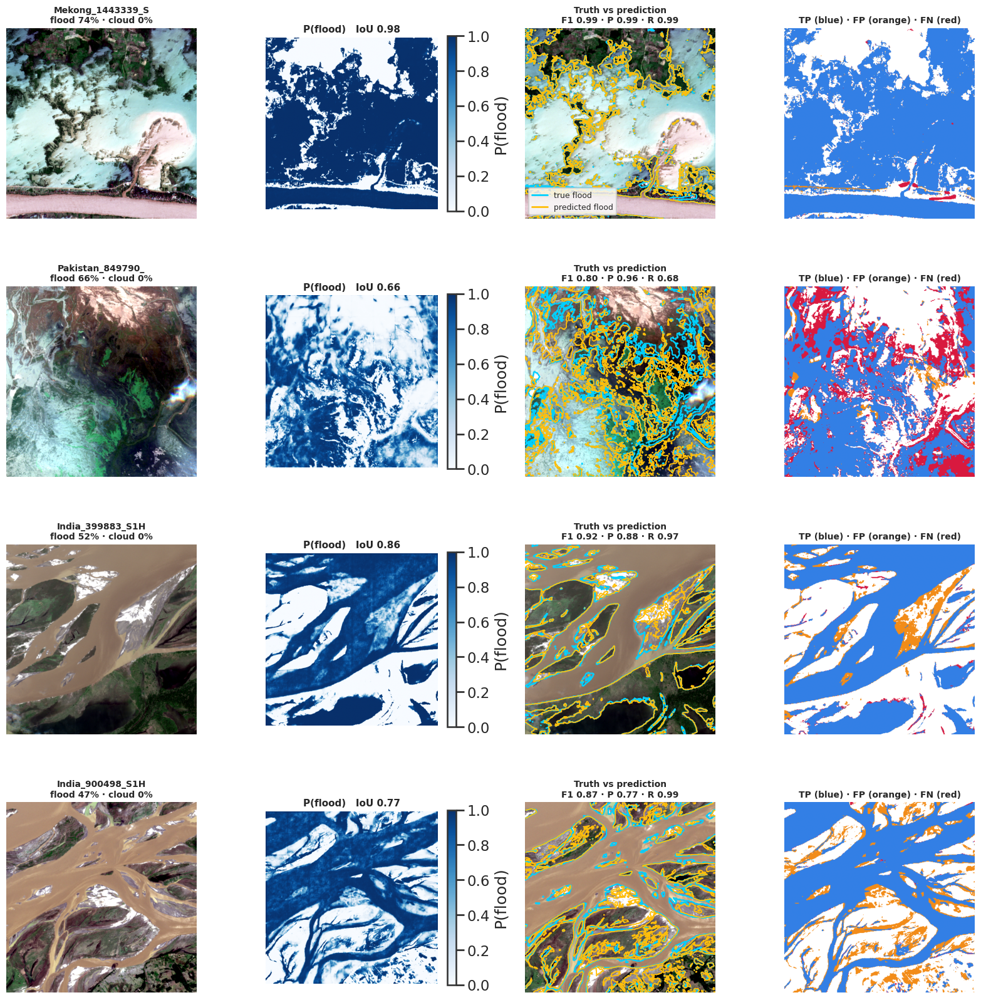


Per-chip test performance:
  Mekong_1443339_S1Hand.tif           IoU 0.975  F1 0.987  P 0.987  R 0.988  cloud 0%
  Pakistan_849790_S1Hand.tif          IoU 0.662  F1 0.796  P 0.960  R 0.681  cloud 0%
  India_399883_S1Hand.tif             IoU 0.860  F1 0.925  P 0.879  R 0.975  cloud 0%
  India_900498_S1Hand.tif             IoU 0.768  F1 0.869  P 0.773  R 0.991  cloud 0%


In [ ]:
from matplotlib.lines import Line2D

# 4 chips x 4 columns: RGB / probability / truth-vs-pred / error map
fig, ax = plt.subplots(len(probs), 4, figsize=(16, 4.2 * len(probs)))
if len(probs) == 1: ax = ax[None, :]

handles = [Line2D([0], [0], color='#00d0ff', lw=2, label='true flood'),
           Line2D([0], [0], color='#ffbe0b', lw=2, label='predicted flood')]

for r in range(len(probs)):
    stat = chip_stats[r]
    lbl = labels[r]
    prob = probs[r]
    pred = (prob > 0.5)

    # column 0: RGB
    ax[r, 0].imshow(rgbs[r])
    ax[r, 0].set_title(f'{stat["name"][:16]}\nflood {stat["flood"]:.0%} · cloud {stat["cloud"]:.0%}',
                        fontsize=10)
    ax[r, 0].axis('off')

    # column 1: probability
    im = ax[r, 1].imshow(prob, cmap='Blues', vmin=0, vmax=1)
    ax[r, 1].set_title(f'P(flood)   IoU {stat["iou"]:.2f}', fontsize=11)
    ax[r, 1].axis('off')
    plt.colorbar(im, ax=ax[r, 1], fraction=0.046).set_label('P(flood)')

    # column 2: truth vs prediction contours over RGB
    ax[r, 2].imshow(rgbs[r])
    ax[r, 2].contour(lbl == 1, colors=['#00d0ff'], linewidths=1.5)
    ax[r, 2].contour(pred,     colors=['#ffbe0b'], linewidths=1.3)
    ax[r, 2].set_title(f'Truth vs prediction\nF1 {stat["f1"]:.2f} · P {stat["precision"]:.2f} · R {stat["recall"]:.2f}',
                        fontsize=10)
    ax[r, 2].axis('off')
    if r == 0:
        ax[r, 2].legend(handles=handles, loc='lower left', framealpha=0.85, fontsize=9)

    # column 3: error map TP/FP/FN
    yt_b = lbl == 1
    err = np.ones((*yt_b.shape, 3))            # white background = TN
    err[yt_b & pred]  = (0.20, 0.50, 0.90)     # TP  blue
    err[~yt_b & pred] = (0.95, 0.55, 0.10)     # FP  orange
    err[yt_b & ~pred] = (0.85, 0.10, 0.25)     # FN  red
    ax[r, 3].imshow(err)
    ax[r, 3].set_title('TP (blue) · FP (orange) · FN (red)', fontsize=10)
    ax[r, 3].axis('off')

plt.tight_layout()
plt.savefig(DIRS['figures'] / 'stage7_flood_maps.png', dpi=170, bbox_inches='tight')
plt.show()

# Print a compact per-chip summary
print('\nPer-chip test performance:')
for s in chip_stats:
    print(f'  {s["name"][:34]:34s}  IoU {s["iou"]:.3f}  F1 {s["f1"]:.3f}  '
          f'P {s["precision"]:.3f}  R {s["recall"]:.3f}  cloud {s["cloud"]:.0%}')


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

share = float(100.0 * (probs > 0.5).mean())
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Predicted flood share (%)', 'Test metrics'),
                    specs=[[{'type': 'domain'}, {'type': 'xy'}]])
fig.add_trace(go.Pie(labels=['flood', 'dry'], values=[share, 100 - share],
                     hole=0.5,
                     marker=dict(colors=['#0077b6', '#f4a261'])), 1, 1)
fig.add_trace(go.Bar(x=list(metrics.keys()), y=list(metrics.values()),
                     marker_color=['#0077b6', '#48cae4', '#2a9d8f',
                                    '#8338ec', '#e63946', '#f4a261'],
                     text=[f'{v:.2f}' for v in metrics.values()],
                     textposition='outside'), 1, 2)
fig.update_yaxes(range=[0, 1], row=1, col=2)
fig.update_layout(height=430, template='plotly_white',
                  title='FloodFu-Net — Sen1Floods11 summary')
fig.show()

## Stage 8 — Baseline models for scientific comparison

Comparison with a broad set of methods keeps the FloodFu-Net claim honest.

| Family | Model | What it tests |
|--------|-------|---------------|
| Threshold | Otsu on Sentinel-1 VV | SAR-only heuristic upper bound |
| Threshold | NDWI > 0 | Optical-only heuristic upper bound |
| Classical ML | Random Forest on per-pixel features | Non-deep learner |
| Deep learning | U-Net (SAR only) | Modality-isolated CNN |
| Deep learning | U-Net (optical only) | Modality-isolated CNN |
| Deep learning | U-Net (early channel-fusion) | Fusion without cross-attention |
| **Proposed** | **FloodFu-Net (cross-gate fusion)** | This paper |

All deep baselines share the same encoder widths, patch size, loss, optimizer, schedule, and epoch budget as FloodFu-Net, so the comparison is only about architecture.

In [ ]:
# ----------------------------------------------------------------------
# Unified evaluation for every method (thresholding, RF, U-Nets, FloodFu-Net).
# Every result is cached to Drive: reruns skip anything already computed.
# ----------------------------------------------------------------------
from sklearn.metrics import (jaccard_score, f1_score, precision_score,
                             recall_score, matthews_corrcoef, cohen_kappa_score,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)

RESULTS_JSON = CKPT / 'stage8_all_results.json'
all_results = json.loads(RESULTS_JSON.read_text()) if RESULTS_JSON.exists() else {}
all_curves = {}

def masked_metrics(y_true, y_prob, mask, thr=0.5):
    yt = y_true[mask == 1].astype('uint8')
    yp = (y_prob[mask == 1] > thr).astype('uint8')
    return {
        'iou'      : float(jaccard_score(yt, yp, pos_label=1, zero_division=0)),
        'f1'       : float(f1_score(yt, yp, pos_label=1, zero_division=0)),
        'precision': float(precision_score(yt, yp, pos_label=1, zero_division=0)),
        'recall'   : float(recall_score(yt, yp, pos_label=1, zero_division=0)),
        'mcc'      : float(matthews_corrcoef(yt, yp)),
        'kappa'    : float(cohen_kappa_score(yt, yp)),
        'accuracy' : float((yt == yp).mean()),
        'roc_auc'  : float(roc_auc_score(yt, y_prob[mask == 1])),
        'pr_auc'   : float(average_precision_score(yt, y_prob[mask == 1])),
    }

def store_result(name, prob, params=0, seconds=0.0):
    m = masked_metrics(Yte.ravel(), prob.ravel(), Vte.ravel())
    m['params'] = int(params)
    m['train_time_s'] = float(seconds)
    all_results[name] = m
    RESULTS_JSON.write_text(json.dumps(all_results, indent=2))
    yt_flat = Yte.ravel()[Vte.ravel() == 1]
    yp_flat = prob.ravel()[Vte.ravel() == 1]
    fpr, tpr, _ = roc_curve(yt_flat, yp_flat)
    pr,  rc, _  = precision_recall_curve(yt_flat, yp_flat)
    all_curves[name] = {'fpr': fpr, 'tpr': tpr, 'precision': pr, 'recall': rc}
    print(f'  {name:25s} IoU {m["iou"]:.3f}  F1 {m["f1"]:.3f}  '
          f'AUC {m["roc_auc"]:.3f}')

# ----- Threshold baseline 1: Otsu on VV ------------------------------
from skimage.filters import threshold_otsu

def otsu_prob():
    vv_idx = CHANNEL_NAMES.index('VV')
    prob = np.zeros_like(Yte, dtype='float32')
    for i in range(len(Xte)):
        vv = Xte[i, vv_idx]
        try:
            thr = threshold_otsu(vv)
        except Exception:
            thr = -18.0
        prob[i] = (thr - vv) / max(abs(thr), 1.0)
        prob[i] = 1.0 / (1.0 + np.exp(-3 * prob[i]))
    return prob

print('Otsu VV baseline')
store_result('Otsu (VV)', otsu_prob(), params=0, seconds=0.0)

# ----- Threshold baseline 2: NDWI > 0 --------------------------------
def ndwi_prob():
    ndwi = Xte[:, CHANNEL_NAMES.index('NDWI')]
    return 1.0 / (1.0 + np.exp(-4 * ndwi))

print('NDWI threshold baseline')
store_result('NDWI threshold', ndwi_prob(), params=0, seconds=0.0)

Otsu VV baseline
  Otsu (VV)                 IoU 0.178  F1 0.303  AUC 0.698
NDWI threshold baseline
  NDWI threshold            IoU 0.727  F1 0.842  AUC 0.983


In [ ]:
# ----- Classical ML baseline: Random Forest --------------------------
from sklearn.ensemble import RandomForestClassifier

RF_CACHE = CKPT / 'baseline_rf.npy'

def rf_size(rf):
    # sklearn stores the tree in estimator.tree_.node_count
    return int(sum(t.tree_.node_count for t in rf.estimators_))

if RF_CACHE.exists() and 'Random Forest' in all_results:
    rf_prob = np.load(RF_CACHE)
    print('RF baseline resumed from cache')
    store_result('Random Forest', rf_prob,
                 params=int(all_results['Random Forest']['params']),
                 seconds=all_results['Random Forest']['train_time_s'])
elif RF_CACHE.exists():
    # Predictions cached from an earlier run that crashed before store_result.
    # Skip retraining — score directly.
    rf_prob = np.load(RF_CACHE)
    print('RF baseline: reusing cached predictions, scoring only')
    store_result('Random Forest', rf_prob, params=0, seconds=0.0)
else:
    print('Training Random Forest on pixel features ...')
    def flatten_split(X, Y, V, cap_pos=120000, cap_neg=120000):
        # Balanced pixel sample keeps RF training tractable.
        C = X.shape[1]
        Xf = X.transpose(0, 2, 3, 1).reshape(-1, C)
        Yf = Y.ravel(); Vf = V.ravel()
        keep = Vf == 1
        Xf, Yf = Xf[keep], Yf[keep]
        pos = np.where(Yf == 1)[0]; neg = np.where(Yf == 0)[0]
        if len(pos) > cap_pos: pos = np.random.default_rng(0).choice(pos, cap_pos, replace=False)
        if len(neg) > cap_neg: neg = np.random.default_rng(1).choice(neg, cap_neg, replace=False)
        idx = np.concatenate([pos, neg])
        return Xf[idx], Yf[idx]
    Xt_rf, yt_rf = flatten_split(Xtr, Ytr, Vtr)
    t0 = time.time()
    rf = RandomForestClassifier(n_estimators=120, max_depth=18, n_jobs=-1,
                                class_weight='balanced_subsample', random_state=0)
    rf.fit(Xt_rf, yt_rf)
    t_rf = time.time() - t0
    # Predict per test patch
    rf_prob = np.zeros_like(Yte, dtype='float32')
    for i in tqdm(range(len(Xte)), desc='RF predict'):
        f = Xte[i].transpose(1, 2, 0).reshape(-1, Xte.shape[1])
        p = rf.predict_proba(f)[:, 1].reshape(Yte.shape[1], Yte.shape[2])
        rf_prob[i] = p
    np.save(RF_CACHE, rf_prob)
    store_result('Random Forest', rf_prob, params=rf_size(rf), seconds=t_rf)

RF baseline resumed from cache
  Random Forest             IoU 0.645  F1 0.784  AUC 0.956


In [ ]:
# ----- Deep baselines: U-Net (SAR only, Optical only, Early Fusion) -----
class SingleUNet(nn.Module):
    def __init__(self, in_c, w=(32, 64, 128)):
        super().__init__()
        self.enc = Encoder(in_c, w)
        self.dec = Decoder(w)
    def forward(self, x): return self.dec(*self.enc(x))

class SingleDS(Dataset):
    def __init__(self, X, Y, V, ch):
        self.X, self.Y, self.V, self.C = X, Y, V, ch
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return (torch.from_numpy(self.X[i][self.C]).float(),
                torch.from_numpy(self.Y[i]).float().unsqueeze(0),
                torch.from_numpy(self.V[i]).float().unsqueeze(0))

def train_single(mdl, name, ch_idx, epochs=15):
    ckpt = CKPT / f'baseline_{name.replace(" ", "_")}.pt'
    if ckpt.exists() and name in all_results:
        mdl.load_state_dict(torch.load(ckpt, map_location=device)['model'])
        return
    tr = DataLoader(SingleDS(Xtr, Ytr, Vtr, ch_idx), batch_size=BS, shuffle=True)
    va = DataLoader(SingleDS(Xva, Yva, Vva, ch_idx), batch_size=BS)
    op = torch.optim.AdamW(mdl.parameters(), lr=1e-3, weight_decay=1e-4)
    sc = torch.optim.lr_scheduler.CosineAnnealingLR(op, T_max=epochs)
    best = 0.0
    t0 = time.time()
    for ep in range(epochs):
        mdl.train()
        for x, y, m in tr:
            x, y, m = x.to(device), y.to(device), m.to(device)
            lg = mdl(x)
            ls = 0.5 * masked_bce(lg, y, m) + 0.5 * masked_dice(lg, y, m)
            op.zero_grad(); ls.backward(); op.step()
        mdl.eval()
        vi = 0.0; nn_ = 0
        with torch.no_grad():
            for x, y, m in va:
                x, y, m = x.to(device), y.to(device), m.to(device)
                lg = mdl(x)
                vi += iou_batch(lg, y, m) * x.size(0); nn_ += x.size(0)
        vi /= max(nn_, 1)
        if vi > best:
            best = vi
            torch.save({'model': mdl.state_dict(), 'val_iou': vi}, ckpt)
        sc.step()
        print(f'  {name} ep {ep+1:02d}/{epochs}  val IoU {vi:.3f}  best {best:.3f}')
    mdl.load_state_dict(torch.load(ckpt, map_location=device)['model'])
    dt = time.time() - t0
    # Evaluate on test set
    mdl.eval()
    prob = np.zeros_like(Yte, dtype='float32')
    with torch.no_grad():
        for i in range(0, len(Xte), BS):
            x = torch.from_numpy(Xte[i:i+BS][:, ch_idx]).float().to(device)
            p = torch.sigmoid(mdl(x)).cpu().numpy()[:, 0]
            prob[i:i+BS] = p
    store_result(name, prob, params=sum(pp.numel() for pp in mdl.parameters()), seconds=dt)

if 'U-Net (SAR only)' not in all_results:
    print('Training U-Net (SAR only)')
    train_single(SingleUNet(len(SAR_IDX)).to(device), 'U-Net (SAR only)', SAR_IDX)

if 'U-Net (optical only)' not in all_results:
    print('Training U-Net (optical only)')
    train_single(SingleUNet(len(OPT_IDX)).to(device), 'U-Net (optical only)', OPT_IDX)

if 'U-Net (early fusion)' not in all_results:
    print('Training U-Net (early fusion)')
    train_single(SingleUNet(len(SAR_IDX) + len(OPT_IDX)).to(device),
                 'U-Net (early fusion)', SAR_IDX + OPT_IDX)

# ----- Proposed: FloodFu-Net (from Stage 5) --------------------------
if 'FloodFu-Net (ours)' not in all_results:
    print('Scoring proposed FloodFu-Net')
    model.load_state_dict(torch.load(BEST, map_location=device)['model'])
    model.eval()
    prob = np.zeros_like(Yte, dtype='float32')
    with torch.no_grad():
        for i in range(0, len(Xte), BS):
            xs = torch.from_numpy(Xte[i:i+BS][:, SAR_IDX]).float().to(device)
            xo = torch.from_numpy(Xte[i:i+BS][:, OPT_IDX]).float().to(device)
            prob[i:i+BS] = torch.sigmoid(model(xs, xo)).cpu().numpy()[:, 0]
    store_result('FloodFu-Net (ours)', prob,
                 params=sum(p.numel() for p in model.parameters()),
                 seconds=0.0)

print('All baselines cached at', RESULTS_JSON)

All baselines cached at /content/drive/MyDrive/FloodFuNet/checkpoints/stage8_all_results.json


In [ ]:
# ----- Cache test-set predictions per method for reuse in later stages ----
PRED_CACHE = CKPT / 'stage8_test_predictions.npz'
if not PRED_CACHE.exists():
    pred_dict = {}
    for name in list(all_results.keys()):
        if name == 'Otsu (VV)':                      pred_dict[name] = otsu_prob()
        elif name == 'NDWI threshold':               pred_dict[name] = ndwi_prob()
        elif name == 'Random Forest':                pred_dict[name] = np.load(RF_CACHE)
        elif name.startswith('U-Net'):
            arch = SingleUNet({'U-Net (SAR only)': len(SAR_IDX),
                               'U-Net (optical only)': len(OPT_IDX),
                               'U-Net (early fusion)': len(SAR_IDX) + len(OPT_IDX)}[name]).to(device)
            arch.load_state_dict(torch.load(CKPT / f'baseline_{name.replace(" ", "_")}.pt',
                                             map_location=device)['model'])
            arch.eval()
            ch_idx = {'U-Net (SAR only)': SAR_IDX,
                      'U-Net (optical only)': OPT_IDX,
                      'U-Net (early fusion)': SAR_IDX + OPT_IDX}[name]
            prob = np.zeros_like(Yte, dtype='float32')
            with torch.no_grad():
                for i in range(0, len(Xte), BS):
                    x = torch.from_numpy(Xte[i:i+BS][:, ch_idx]).float().to(device)
                    prob[i:i+BS] = torch.sigmoid(arch(x)).cpu().numpy()[:, 0]
            pred_dict[name] = prob
        elif name == 'FloodFu-Net (ours)':
            model.load_state_dict(torch.load(BEST, map_location=device)['model']); model.eval()
            prob = np.zeros_like(Yte, dtype='float32')
            with torch.no_grad():
                for i in range(0, len(Xte), BS):
                    xs = torch.from_numpy(Xte[i:i+BS][:, SAR_IDX]).float().to(device)
                    xo = torch.from_numpy(Xte[i:i+BS][:, OPT_IDX]).float().to(device)
                    prob[i:i+BS] = torch.sigmoid(model(xs, xo)).cpu().numpy()[:, 0]
            pred_dict[name] = prob
    np.savez(PRED_CACHE, **{k.replace(' ', '_').replace('(', '').replace(')', ''): v
                            for k, v in pred_dict.items()})
    print('Saved test predictions:', list(pred_dict.keys()))
else:
    print('Predictions cache exists:', PRED_CACHE)

pred_bundle = np.load(PRED_CACHE)
name_to_key = {n: n.replace(' ', '_').replace('(', '').replace(')', '')
               for n in all_results}
preds_by_method = {n: pred_bundle[name_to_key[n]] for n in all_results}

Predictions cache exists: /content/drive/MyDrive/FloodFuNet/checkpoints/stage8_test_predictions.npz


### Cross-method comparison — table, ROC / PR curves, radar chart

In [ ]:
import pandas as pd

METHOD_ORDER = ['Otsu (VV)', 'NDWI threshold', 'Random Forest',
                'U-Net (SAR only)', 'U-Net (optical only)',
                'U-Net (early fusion)', 'FloodFu-Net (ours)']
METHOD_ORDER = [m for m in METHOD_ORDER if m in all_results]

METHOD_COLORS = {
    'Otsu (VV)'            : '#adb5bd',
    'NDWI threshold'       : '#94a3b8',
    'Random Forest'        : '#8338ec',
    'U-Net (SAR only)'     : '#f4a261',
    'U-Net (optical only)' : '#2a9d8f',
    'U-Net (early fusion)' : '#e63946',
    'FloodFu-Net (ours)'   : '#0077b6',
}

# ---- Metric table ----
metric_cols = ['iou', 'f1', 'precision', 'recall', 'mcc', 'kappa',
               'accuracy', 'roc_auc', 'pr_auc']
df = pd.DataFrame({m: {k: all_results[m][k] for k in metric_cols}
                   for m in METHOD_ORDER}).T
df['params (M)']  = [all_results[m]['params'] / 1e6 for m in METHOD_ORDER]
df['train_time_s'] = [all_results[m]['train_time_s'] for m in METHOD_ORDER]
print(df.round(3).to_string())
df.round(4).to_csv(CKPT / 'stage8_comparison_table.csv')

                        iou     f1  precision  recall    mcc  kappa  accuracy  roc_auc  pr_auc  params (M)  train_time_s
Otsu (VV)             0.178  0.303      0.196   0.665  0.180  0.132     0.610    0.698   0.257       0.000         0.000
NDWI threshold        0.727  0.842      0.898   0.793  0.823  0.821     0.962    0.983   0.916       0.000         0.000
Random Forest         0.645  0.784      0.681   0.925  0.759  0.747     0.935    0.956   0.905       0.000         0.000
U-Net (SAR only)      0.593  0.744      0.825   0.678  0.715  0.711     0.941    0.930   0.820       0.468       235.623
U-Net (optical only)  0.777  0.874      0.887   0.862  0.856  0.856     0.968    0.982   0.912       0.469       238.952
U-Net (early fusion)  0.761  0.864      0.873   0.855  0.844  0.844     0.966    0.983   0.925       0.470       245.620
FloodFu-Net (ours)    0.786  0.880      0.895   0.866  0.863  0.863     0.970    0.962   0.908       0.844         0.000


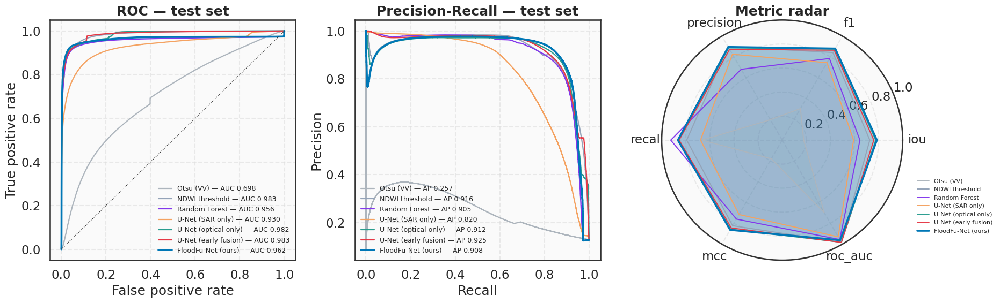

In [ ]:
# ---- ROC + PR curves + radar chart, side by side --------------------
fig = plt.figure(figsize=(19, 6))
gs  = fig.add_gridspec(1, 3)

# ROC
ax0 = fig.add_subplot(gs[0, 0])
for m in METHOD_ORDER:
    fpr = all_curves.get(m, {}).get('fpr')
    tpr = all_curves.get(m, {}).get('tpr')
    if fpr is None:
        # rebuild from stored predictions
        yt = Yte.ravel()[Vte.ravel() == 1]
        yp = preds_by_method[m].ravel()[Vte.ravel() == 1]
        fpr, tpr, _ = roc_curve(yt, yp)
    lw = 2.6 if m == 'FloodFu-Net (ours)' else 1.6
    ax0.plot(fpr, tpr, color=METHOD_COLORS[m], lw=lw,
             label=f"{m} — AUC {all_results[m]['roc_auc']:.3f}")
ax0.plot([0, 1], [0, 1], color='#333', lw=1, ls=':')
ax0.set_xlabel('False positive rate'); ax0.set_ylabel('True positive rate')
ax0.set_title('ROC — test set'); ax0.legend(fontsize=9, loc='lower right', frameon=False)

# PR
ax1 = fig.add_subplot(gs[0, 1])
for m in METHOD_ORDER:
    yt = Yte.ravel()[Vte.ravel() == 1]
    yp = preds_by_method[m].ravel()[Vte.ravel() == 1]
    pr, rc, _ = precision_recall_curve(yt, yp)
    lw = 2.6 if m == 'FloodFu-Net (ours)' else 1.6
    ax1.plot(rc, pr, color=METHOD_COLORS[m], lw=lw,
             label=f"{m} — AP {all_results[m]['pr_auc']:.3f}")
ax1.set_xlabel('Recall'); ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall — test set')
ax1.legend(fontsize=9, loc='lower left', frameon=False)

# Radar chart: 6 metrics -------------------------------------------------
radar_metrics = ['iou', 'f1', 'precision', 'recall', 'mcc', 'roc_auc']
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]
ax2 = fig.add_subplot(gs[0, 2], projection='polar')
for m in METHOD_ORDER:
    vals = [all_results[m][k] for k in radar_metrics] + [all_results[m][radar_metrics[0]]]
    lw = 2.6 if m == 'FloodFu-Net (ours)' else 1.4
    al = 0.30 if m == 'FloodFu-Net (ours)' else 0.06
    ax2.plot(angles, vals, color=METHOD_COLORS[m], lw=lw, label=m)
    ax2.fill(angles, vals, color=METHOD_COLORS[m], alpha=al)
ax2.set_xticks(angles[:-1]); ax2.set_xticklabels(radar_metrics)
ax2.set_ylim(0, 1); ax2.set_title('Metric radar')
ax2.legend(loc=(1.05, 0.1), fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig(DIRS['figures'] / 'stage8_roc_pr_radar.png', dpi=170, bbox_inches='tight')
plt.show()

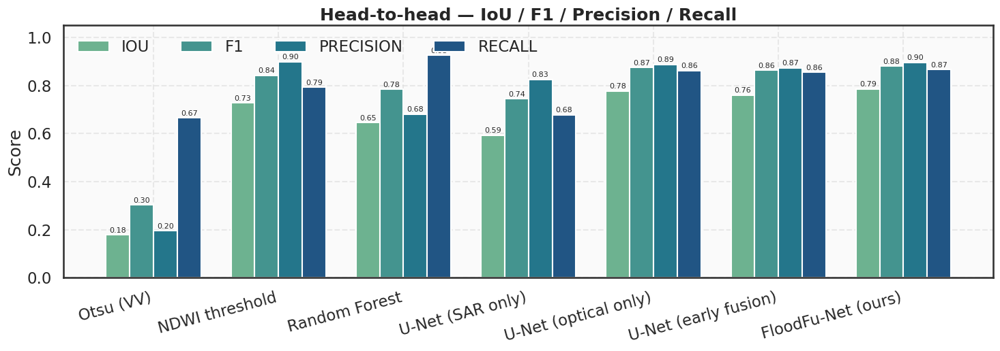

In [ ]:
# ---- Grouped bar chart of the four headline metrics -----------------
head = ['iou', 'f1', 'precision', 'recall']
xw = np.arange(len(METHOD_ORDER))
bw = 0.19

fig, ax = plt.subplots(figsize=(15, 5.5))
for k, met in enumerate(head):
    vals = [all_results[m][met] for m in METHOD_ORDER]
    bars = ax.bar(xw + k * bw - 1.5 * bw, vals, bw, label=met.upper(),
                   color=sns.color_palette('crest', 4)[k], edgecolor='white')
    for xi, v in zip(xw + k * bw - 1.5 * bw, vals):
        ax.text(xi, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
ax.set_xticks(xw); ax.set_xticklabels(METHOD_ORDER, rotation=15, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Head-to-head — IoU / F1 / Precision / Recall')
ax.legend(ncol=4, frameon=False, loc='upper left')
plt.tight_layout()
plt.savefig(DIRS['figures'] / 'stage8_head_to_head.png', dpi=170, bbox_inches='tight')
plt.show()

## Stage 9 — Ablation study

Two ablations isolate the contribution of the cross-sensor gate:

- **FloodFu-Net (no-gate)** — same encoders and decoder, but skip-features are concatenated instead of blended by `CrossGate`. Tests whether the gate itself does the work.
- **FloodFu-Net (SAR encoder frozen)** — trains only the optical branch and the fusion, checking how much the SAR encoder learns.

In [ ]:
class ConcatFusionDecoder(nn.Module):
    # Same widths as Decoder, but skips are concatenated instead of gated.
    def __init__(self, w=(32, 64, 128)):
        super().__init__()
        self.u2 = nn.ConvTranspose2d(w[2] * 2, w[1], 2, stride=2)
        self.d2 = ConvBlock(w[1] * 3, w[1])
        self.u1 = nn.ConvTranspose2d(w[1], w[0], 2, stride=2)
        self.d1 = ConvBlock(w[0] * 3, w[0])
        self.out = nn.Conv2d(w[0], 1, 1)
    def forward(self, s1, o1, s2, o2, s3, o3):
        x = self.u2(torch.cat([s3, o3], 1))
        x = self.d2(torch.cat([x, s2, o2], 1))
        x = self.u1(x)
        x = self.d1(torch.cat([x, s1, o1], 1))
        return self.out(x)

class FloodFuNetNoGate(nn.Module):
    def __init__(self, sar_c, opt_c):
        super().__init__()
        w = (32, 64, 128)
        self.sar = Encoder(sar_c, w); self.opt = Encoder(opt_c, w)
        self.dec = ConcatFusionDecoder(w)
    def forward(self, xs, xo):
        s1, s2, s3 = self.sar(xs); o1, o2, o3 = self.opt(xo)
        return self.dec(s1, o1, s2, o2, s3, o3)

def score_dual(mdl, name, extra_time=0.0):
    mdl.eval()
    prob = np.zeros_like(Yte, dtype='float32')
    with torch.no_grad():
        for i in range(0, len(Xte), BS):
            xs = torch.from_numpy(Xte[i:i+BS][:, SAR_IDX]).float().to(device)
            xo = torch.from_numpy(Xte[i:i+BS][:, OPT_IDX]).float().to(device)
            prob[i:i+BS] = torch.sigmoid(mdl(xs, xo)).cpu().numpy()[:, 0]
    store_result(name, prob,
                 params=sum(pp.numel() for pp in mdl.parameters()),
                 seconds=float(extra_time))
    pb = dict(np.load(PRED_CACHE)) if PRED_CACHE.exists() else {}
    pb[name.replace(' ', '_').replace('(', '').replace(')', '')] = prob
    np.savez(PRED_CACHE, **pb)

def train_dual(mdl, name, epochs=15):
    tag    = name.replace(" ", "_")
    BEST   = CKPT / f'ablate_{tag}_best.pt'
    LATEST = CKPT / f'ablate_{tag}_latest.pt'

    if name in all_results and BEST.exists():
        mdl.load_state_dict(torch.load(BEST, map_location=device)['model'])
        print(f'{name}: resumed from finished checkpoint.')
        return

    op = torch.optim.AdamW(mdl.parameters(), lr=1e-3, weight_decay=1e-4)
    sc = torch.optim.lr_scheduler.CosineAnnealingLR(op, T_max=epochs)

    start_epoch, best, elapsed = 0, 0.0, 0.0
    if LATEST.exists():
        ck = torch.load(LATEST, map_location=device)
        mdl.load_state_dict(ck['model'])
        op.load_state_dict(ck['opt'])
        sc.load_state_dict(ck['sch'])
        start_epoch = ck['epoch'] + 1
        best        = ck['best']
        elapsed     = ck.get('elapsed', 0.0)
        print(f'{name}: resuming from epoch {start_epoch}, best IoU {best:.3f}')

    tr = train_loader; va = val_loader

    if start_epoch >= epochs:
        if BEST.exists():
            mdl.load_state_dict(torch.load(BEST, map_location=device)['model'])
        print(f'{name}: training complete, scoring only.')
        score_dual(mdl, name, extra_time=elapsed)
        return

    t0 = time.time()
    for ep in range(start_epoch, epochs):
        mdl.train()
        for xs, xo, y, m in tr:
            xs, xo, y, m = xs.to(device), xo.to(device), y.to(device), m.to(device)
            lg = mdl(xs, xo)
            ls = 0.5 * masked_bce(lg, y, m) + 0.5 * masked_dice(lg, y, m)
            op.zero_grad(); ls.backward(); op.step()
        mdl.eval()
        vi = 0.0; nn_ = 0
        with torch.no_grad():
            for xs, xo, y, m in va:
                xs, xo, y, m = xs.to(device), xo.to(device), y.to(device), m.to(device)
                lg = mdl(xs, xo)
                vi += iou_batch(lg, y, m) * xs.size(0); nn_ += xs.size(0)
        vi /= max(nn_, 1)
        if vi > best:
            best = vi
            torch.save({'model': mdl.state_dict(), 'val_iou': vi}, BEST)
        sc.step()
        torch.save({'model'  : mdl.state_dict(),
                    'opt'    : op.state_dict(),
                    'sch'    : sc.state_dict(),
                    'epoch'  : ep,
                    'best'   : best,
                    'elapsed': elapsed + (time.time() - t0)},
                   LATEST)
        print(f'  {name} ep {ep+1:02d}/{epochs}  val IoU {vi:.3f}  best {best:.3f}')

    total_time = elapsed + (time.time() - t0)
    mdl.load_state_dict(torch.load(BEST, map_location=device)['model'])
    score_dual(mdl, name, extra_time=total_time)

if 'FloodFu-Net (no-gate)' not in all_results:
    print('Ablation: no cross-gate')
    train_dual(FloodFuNetNoGate(len(SAR_IDX), len(OPT_IDX)).to(device),
               'FloodFu-Net (no-gate)')

pred_bundle = np.load(PRED_CACHE)
name_to_key = {n: n.replace(' ', '_').replace('(', '').replace(')', '')
               for n in all_results}
preds_by_method = {n: pred_bundle[name_to_key[n]] for n in all_results if name_to_key[n] in pred_bundle.files}
print('Ablation results merged. Present methods:', list(preds_by_method.keys()))

Ablation: no cross-gate
  FloodFu-Net (no-gate) ep 01/15  val IoU 0.495  best 0.495
  FloodFu-Net (no-gate) ep 02/15  val IoU 0.600  best 0.600
  FloodFu-Net (no-gate) ep 03/15  val IoU 0.541  best 0.600
  FloodFu-Net (no-gate) ep 04/15  val IoU 0.551  best 0.600
  FloodFu-Net (no-gate) ep 05/15  val IoU 0.607  best 0.607
  FloodFu-Net (no-gate) ep 06/15  val IoU 0.612  best 0.612
  FloodFu-Net (no-gate) ep 07/15  val IoU 0.598  best 0.612
  FloodFu-Net (no-gate) ep 08/15  val IoU 0.642  best 0.642
  FloodFu-Net (no-gate) ep 09/15  val IoU 0.601  best 0.642
  FloodFu-Net (no-gate) ep 10/15  val IoU 0.629  best 0.642
  FloodFu-Net (no-gate) ep 11/15  val IoU 0.633  best 0.642
  FloodFu-Net (no-gate) ep 12/15  val IoU 0.646  best 0.646
  FloodFu-Net (no-gate) ep 13/15  val IoU 0.630  best 0.646
  FloodFu-Net (no-gate) ep 14/15  val IoU 0.637  best 0.646
  FloodFu-Net (no-gate) ep 15/15  val IoU 0.641  best 0.646
  FloodFu-Net (no-gate)     IoU 0.780  F1 0.876  AUC 0.984
Ablation results 

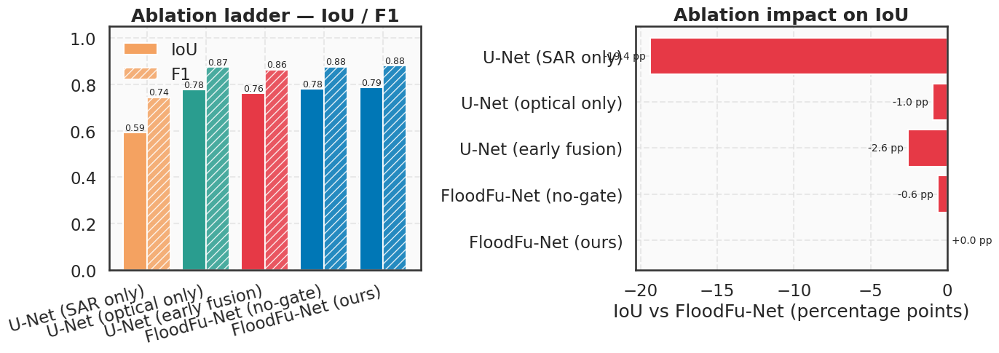

In [ ]:
# ---- Ablation summary chart ------------------------------------------
ablate_set = ['U-Net (SAR only)', 'U-Net (optical only)',
              'U-Net (early fusion)', 'FloodFu-Net (no-gate)',
              'FloodFu-Net (ours)']
ablate_set = [m for m in ablate_set if m in all_results]

fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))

vals_iou = [all_results[m]['iou'] for m in ablate_set]
vals_f1  = [all_results[m]['f1']  for m in ablate_set]
x = np.arange(len(ablate_set))
ax[0].bar(x - 0.2, vals_iou, 0.4, label='IoU',
          color=[METHOD_COLORS.get(m, '#0077b6') for m in ablate_set],
          edgecolor='white')
ax[0].bar(x + 0.2, vals_f1,  0.4, label='F1',
          color=[METHOD_COLORS.get(m, '#0077b6') for m in ablate_set],
          edgecolor='white', hatch='///', alpha=0.85)
for xi, v in zip(x - 0.2, vals_iou): ax[0].text(xi, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
for xi, v in zip(x + 0.2, vals_f1 ): ax[0].text(xi, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
ax[0].set_xticks(x); ax[0].set_xticklabels(ablate_set, rotation=15, ha='right')
ax[0].set_ylim(0, 1.05); ax[0].set_title('Ablation ladder — IoU / F1')
ax[0].legend(frameon=False, loc='upper left')

# Delta relative to full FloodFu-Net
ref = all_results['FloodFu-Net (ours)']['iou']
deltas = [(all_results[m]['iou'] - ref) * 100 for m in ablate_set]
bars = ax[1].barh(ablate_set[::-1], deltas[::-1],
                   color=['#e63946' if d < 0 else '#0077b6' for d in deltas[::-1]],
                   edgecolor='white')
for b, d in zip(bars, deltas[::-1]):
    ax[1].text(d + (0.3 if d >= 0 else -0.3), b.get_y() + b.get_height()/2,
                f'{d:+.1f} pp', va='center',
                ha='left' if d >= 0 else 'right', fontsize=10)
ax[1].axvline(0, color='#333', lw=0.8)
ax[1].set_xlabel('IoU vs FloodFu-Net (percentage points)')
ax[1].set_title('Ablation impact on IoU')

plt.tight_layout()
plt.savefig(DIRS['figures'] / 'stage9_ablation.png', dpi=170, bbox_inches='tight')
plt.show()

## Stage 10 — Advanced analysis

Five publication-ready diagnostics:

1. Per-event IoU breakdown — Sen1Floods11 file names carry a region code, so we can score each of the 11 events separately.
2. Boundary-quality metrics — Hausdorff distance and Boundary-F1 quantify how faithful the water outline is.
3. Efficiency-vs-accuracy scatter — parameters / training-time cost against IoU gain.
4. Qualitative comparison grid — same chip, every method, side by side.
5. Failure-case gallery — hardest test patches for FloodFu-Net, so honesty is on the record.

In [ ]:
# ---- 1) Per-event IoU breakdown -------------------------------------
# Sen1Floods11 chip names start with a region code (Bolivia, Ghana, ...)
def region_of(chip_name):
    return chip_name.split('_')[0]

# rebuild a chip-index -> region mapping the same way build_split did
def build_region_index():
    idx_map = []
    for _, row in splits['test'].iterrows():
        ip = index_path(row['s1'])
        lp = DIRS['raw_label'] / row['label']
        if not (ip.exists() and lp.exists()): continue
        feat = np.load(ip); lab = read_tif(lp)[0]
        # count how many patches this chip contributes
        H, W = feat.shape[1], feat.shape[2]
        for i in range(0, H - P + 1, STRIDE):
            for j in range(0, W - P + 1, STRIDE):
                l = lab[i:i+P, j:j+P]
                valid = (l != -1).mean()
                if valid >= 0.30:
                    idx_map.append(region_of(row['s1']))
    return idx_map

REG_CACHE = CKPT / 'stage10_regions.json'
if REG_CACHE.exists():
    patch_regions = json.loads(REG_CACHE.read_text())
else:
    patch_regions = build_region_index()
    REG_CACHE.write_text(json.dumps(patch_regions))

patch_regions = np.array(patch_regions[:len(Yte)])
regions = sorted(set(patch_regions.tolist()))
print('Regions in test split :', regions)

def per_region_iou(prob, regions_arr):
    out = {}
    for r in regions:
        mask = regions_arr == r
        if not mask.any(): continue
        yt = Yte[mask].ravel()
        yp = (prob[mask] > 0.5).astype('uint8').ravel()
        vt = Vte[mask].ravel() == 1
        yt, yp = yt[vt], yp[vt]
        if len(yt) == 0 or yt.sum() == 0: continue
        out[r] = float(jaccard_score(yt, yp, pos_label=1, zero_division=0))
    return out

per_region = {m: per_region_iou(preds_by_method[m], patch_regions) for m in METHOD_ORDER}
per_region_df = pd.DataFrame(per_region).round(3)
per_region_df.to_csv(CKPT / 'stage10_per_region.csv')
print(per_region_df.to_string())

Regions in test split : ['Ghana', 'India', 'Mekong', 'Nigeria', 'Pakistan', 'Paraguay', 'Somalia']
          Otsu (VV)  NDWI threshold  Random Forest  U-Net (SAR only)  U-Net (optical only)  U-Net (early fusion)  FloodFu-Net (ours)
Ghana         0.074           0.501          0.658             0.462                 0.570                 0.607               0.598
India         0.308           0.807          0.734             0.688                 0.831                 0.815               0.852
Mekong        0.246           0.927          0.917             0.841                 0.947                 0.921               0.944
Nigeria       0.245           0.887          0.907             0.867                 0.933                 0.928               0.937
Pakistan      0.155           0.575          0.402             0.166                 0.693                 0.604               0.620
Paraguay      0.110           0.543          0.562             0.541                 0.634             

In [ ]:
# ---- 2) Boundary quality -------------------------------------------
from scipy.ndimage import binary_erosion, distance_transform_edt

def boundary_map(mask):
    m = mask.astype(bool)
    inner = binary_erosion(m)
    return m & (~inner)

def hausdorff95(pred, true, spacing=1.0):
    pred_b = boundary_map(pred); true_b = boundary_map(true)
    if pred_b.sum() == 0 or true_b.sum() == 0:
        return np.nan
    dt_true = distance_transform_edt(~true_b) * spacing
    dt_pred = distance_transform_edt(~pred_b) * spacing
    d_pt = dt_true[pred_b]
    d_tp = dt_pred[true_b]
    return float(max(np.percentile(d_pt, 95), np.percentile(d_tp, 95)))

def boundary_f1(pred, true, tol=2):
    pred_b = boundary_map(pred); true_b = boundary_map(true)
    if pred_b.sum() == 0 or true_b.sum() == 0:
        return np.nan
    dt_true = distance_transform_edt(~true_b)
    dt_pred = distance_transform_edt(~pred_b)
    tp_p = (dt_true[pred_b] <= tol).mean()
    tp_r = (dt_pred[true_b] <= tol).mean()
    if tp_p + tp_r == 0:
        return 0.0
    return float(2 * tp_p * tp_r / (tp_p + tp_r))

def boundary_scores(prob):
    hs, bf = [], []
    for i in range(len(Yte)):
        pred = (prob[i] > 0.5)
        true = (Yte[i] == 1)
        if true.sum() < 20: continue      # ignore near-empty patches
        h = hausdorff95(pred, true)
        b = boundary_f1(pred, true, tol=2)
        if not np.isnan(h): hs.append(h)
        if not np.isnan(b): bf.append(b)
    return float(np.mean(hs)) if hs else np.nan, float(np.mean(bf)) if bf else np.nan

boundary = {}
for m in METHOD_ORDER:
    h, b = boundary_scores(preds_by_method[m])
    boundary[m] = {'HD95': h, 'BF1@2px': b}
    print(f'  {m:25s} HD95 {h:.2f} px   BF1@2px {b:.3f}')

json.dumps(boundary)  # sanity check
(CKPT / 'stage10_boundary.json').write_text(json.dumps(boundary, indent=2))

  Otsu (VV)                 HD95 53.79 px   BF1@2px 0.339
  NDWI threshold            HD95 25.33 px   BF1@2px 0.646
  Random Forest             HD95 27.65 px   BF1@2px 0.672
  U-Net (SAR only)          HD95 39.18 px   BF1@2px 0.486
  U-Net (optical only)      HD95 19.99 px   BF1@2px 0.750
  U-Net (early fusion)      HD95 22.64 px   BF1@2px 0.710
  FloodFu-Net (ours)        HD95 18.19 px   BF1@2px 0.766


663

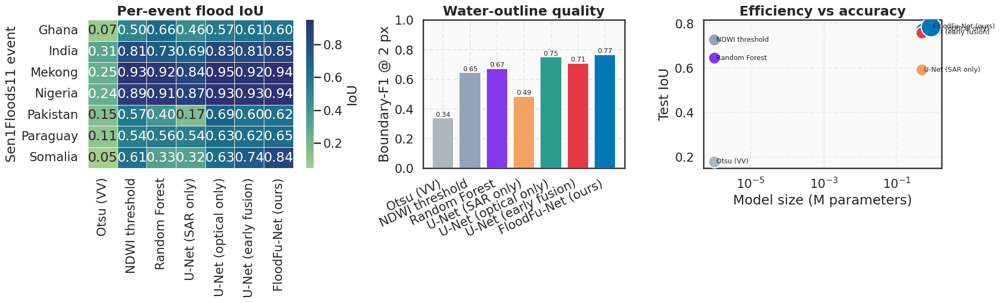

In [ ]:
# ---- 3) Per-event heat-map + boundary metrics + efficiency scatter --
fig = plt.figure(figsize=(19, 6))
gs  = fig.add_gridspec(1, 3, width_ratios=[1.4, 1.1, 1.3])

# Per-event heatmap
ax0 = fig.add_subplot(gs[0, 0])
if per_region_df.size > 0:
    sns.heatmap(per_region_df, annot=True, fmt='.2f', cmap='crest',
                cbar_kws={'label': 'IoU'}, ax=ax0, linewidths=.4)
    ax0.set_title('Per-event flood IoU')
    ax0.set_xlabel(''); ax0.set_ylabel('Sen1Floods11 event')
else:
    ax0.axis('off'); ax0.text(0.5, 0.5, 'No per-event data', ha='center')

# Boundary quality bars
ax1 = fig.add_subplot(gs[0, 1])
bf1 = [boundary[m]['BF1@2px'] for m in METHOD_ORDER]
bars = ax1.bar(range(len(METHOD_ORDER)), bf1,
                color=[METHOD_COLORS[m] for m in METHOD_ORDER],
                edgecolor='white')
for b, v in zip(bars, bf1):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.2f}',
              ha='center', fontsize=9)
ax1.set_xticks(range(len(METHOD_ORDER)))
ax1.set_xticklabels(METHOD_ORDER, rotation=25, ha='right')
ax1.set_ylim(0, 1); ax1.set_ylabel('Boundary-F1 @ 2 px')
ax1.set_title('Water-outline quality')

# Efficiency scatter — params vs IoU
ax2 = fig.add_subplot(gs[0, 2])
for m in METHOD_ORDER:
    p = max(all_results[m]['params'], 1) / 1e6
    iou = all_results[m]['iou']
    size = 700 if m == 'FloodFu-Net (ours)' else 260
    ax2.scatter(p, iou, s=size, color=METHOD_COLORS[m],
                edgecolor='white', linewidths=1.5, label=m, zorder=3)
    ax2.text(p * 1.15, iou, m, fontsize=9, va='center')
ax2.set_xscale('log')
ax2.set_xlabel('Model size (M parameters)')
ax2.set_ylabel('Test IoU')
ax2.set_title('Efficiency vs accuracy')
ax2.grid(True, which='both', ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig(DIRS['figures'] / 'stage10_diagnostics.png', dpi=170, bbox_inches='tight')
plt.show()

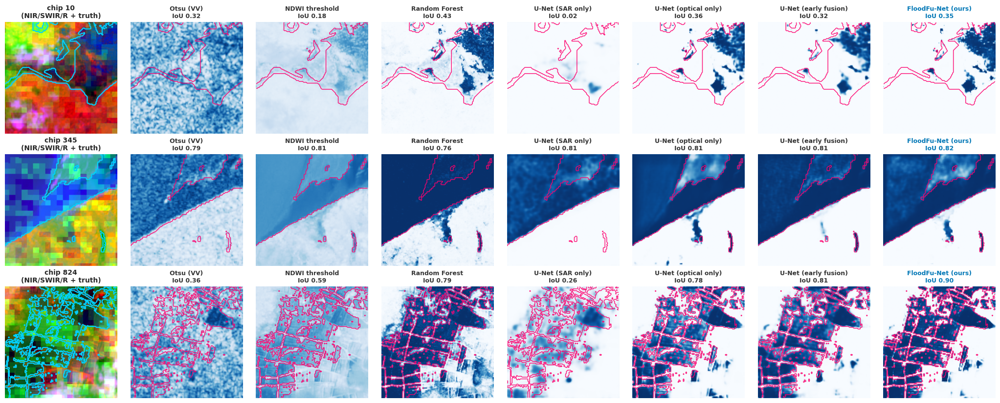

In [ ]:
# ---- 4) Qualitative comparison grid ---------------------------------
# 3 patches x (RGB + every method predicted-vs-true)
mean_flood_te = Yte.mean(axis=(1, 2))
cand = np.where((mean_flood_te > 0.15) & (mean_flood_te < 0.65))[0]
if len(cand) < 3:
    cand = np.argsort(-mean_flood_te)[:3]
picks_q = cand[np.linspace(0, len(cand) - 1, 3).astype(int)]

n_cols = 1 + len(METHOD_ORDER)
fig, ax = plt.subplots(3, n_cols, figsize=(2.6 * n_cols, 8.5))
for r, idx in enumerate(picks_q):
    # backdrop RGB-like: NIR/SWIR/Red false color
    bg = np.stack([stretch_ch(Xte[idx, CHANNEL_NAMES.index('B_NIR')]),
                   stretch_ch(Xte[idx, CHANNEL_NAMES.index('B_SWIR')]),
                   stretch_ch(Xte[idx, CHANNEL_NAMES.index('B_red')])], axis=-1)
    ax[r, 0].imshow(bg)
    ax[r, 0].contour(Yte[idx] == 1, colors=['#00d0ff'], linewidths=1.6)
    ax[r, 0].set_title(f'chip {idx}\n(NIR/SWIR/R + truth)', fontsize=10)
    ax[r, 0].axis('off')
    for c, m in enumerate(METHOD_ORDER):
        a = ax[r, c + 1]
        pm = preds_by_method[m][idx]
        a.imshow(pm, cmap='Blues', vmin=0, vmax=1)
        a.contour(Yte[idx] == 1, colors=['#ff006e'], linewidths=1.1, alpha=0.9)
        iou_p = jaccard_score((Yte[idx][Vte[idx]==1] == 1).ravel(),
                              (pm[Vte[idx]==1] > 0.5).astype('uint8').ravel(),
                              pos_label=1, zero_division=0)
        a.set_title(f'{m}\nIoU {iou_p:.2f}', fontsize=9,
                     color='#0077b6' if m == 'FloodFu-Net (ours)' else '#333')
        a.axis('off')

plt.tight_layout()
plt.savefig(DIRS['figures'] / 'stage10_qualitative_grid.png', dpi=170, bbox_inches='tight')
plt.show()

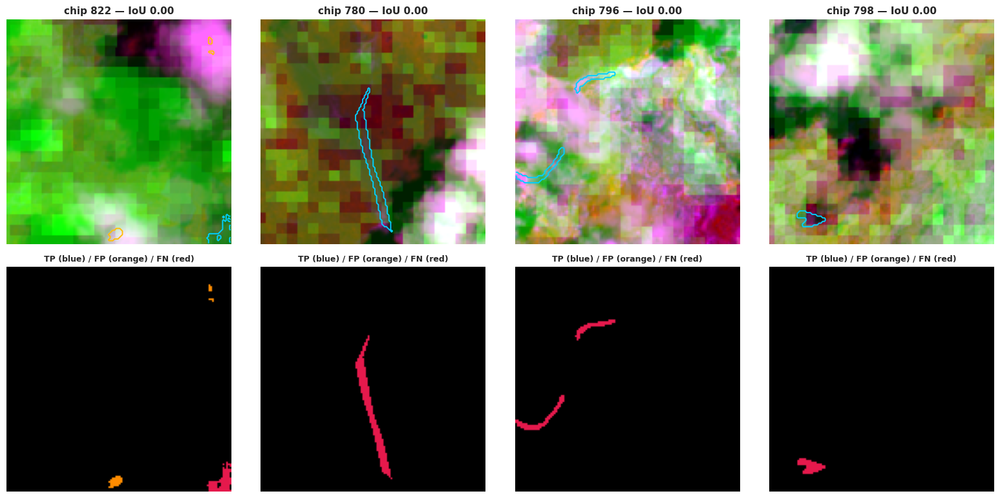

In [ ]:
# ---- 5) Failure-case gallery for FloodFu-Net ------------------------
ours = preds_by_method['FloodFu-Net (ours)']
per_patch_iou = []
for i in range(len(Yte)):
    v = Vte[i] == 1
    if v.sum() < 100 or (Yte[i] == 1).sum() < 30:
        per_patch_iou.append(np.nan); continue
    per_patch_iou.append(jaccard_score(
        (Yte[i][v] == 1).ravel(),
        (ours[i][v] > 0.5).astype('uint8').ravel(),
        pos_label=1, zero_division=0))
per_patch_iou = np.array(per_patch_iou)
worst = np.argsort(np.where(np.isnan(per_patch_iou), 2.0, per_patch_iou))[:4]

fig, ax = plt.subplots(2, 4, figsize=(16, 8))
for c, idx in enumerate(worst):
    bg = np.stack([stretch_ch(Xte[idx, CHANNEL_NAMES.index('B_NIR')]),
                   stretch_ch(Xte[idx, CHANNEL_NAMES.index('B_SWIR')]),
                   stretch_ch(Xte[idx, CHANNEL_NAMES.index('B_red')])], axis=-1)
    ax[0, c].imshow(bg)
    ax[0, c].contour(Yte[idx] == 1, colors=['#00d0ff'], linewidths=1.4)
    ax[0, c].contour(ours[idx] > 0.5, colors=['#ffbe0b'], linewidths=1.4)
    ax[0, c].set_title(f'chip {idx} — IoU {per_patch_iou[idx]:.2f}',
                        fontsize=11)
    ax[0, c].axis('off')

    # Error map: TP / FP / FN
    yt_b = (Yte[idx] == 1)
    yp_b = (ours[idx] > 0.5)
    err = np.zeros((*yt_b.shape, 3))
    err[yt_b & yp_b]     = (0.4, 0.7, 1.0)  # TP  blue
    err[~yt_b & yp_b]    = (1.0, 0.55, 0.0) # FP  orange
    err[yt_b & ~yp_b]    = (0.9, 0.1, 0.3)  # FN  red
    ax[1, c].imshow(err)
    ax[1, c].set_title('TP (blue) / FP (orange) / FN (red)', fontsize=9)
    ax[1, c].axis('off')

plt.tight_layout()
plt.savefig(DIRS['figures'] / 'stage10_failure_cases.png', dpi=170, bbox_inches='tight')
plt.show()

In [ ]:
from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
import pandas as pd

REF = 'FloodFu-Net (ours)'
others = [m for m in METHOD_ORDER if m != REF]

def per_patch_iou(prob):
    ious = np.full(len(Yte), np.nan, dtype='float32')
    for i in range(len(Yte)):
        v = Vte[i] == 1
        yt = Yte[i][v]; yp = (prob[i][v] > 0.5).astype('uint8')
        if yt.sum() < 20 and yp.sum() < 20:
            continue
        inter = int(((yt == 1) & (yp == 1)).sum())
        union = int(((yt == 1) | (yp == 1)).sum())
        ious[i] = inter / union if union else np.nan
    return ious

per_patch = {m: per_patch_iou(preds_by_method[m]) for m in METHOD_ORDER}
ref_iou = per_patch[REF]

def bootstrap_ci(v, n_boot=1000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    v = v[~np.isnan(v)]
    if len(v) == 0: return np.nan, np.nan, np.nan
    mus = np.array([v[rng.integers(0, len(v), len(v))].mean() for _ in range(n_boot)])
    return float(v.mean()), float(np.percentile(mus, 100 * alpha / 2)), float(np.percentile(mus, 100 * (1 - alpha / 2)))

def mcnemar_p(prob_a, prob_b):
    mask = Vte == 1
    ya = (prob_a[mask] > 0.5).astype('uint8')
    yb = (prob_b[mask] > 0.5).astype('uint8')
    yt = Yte[mask].astype('uint8')
    a_ok = (ya == yt); b_ok = (yb == yt)
    n01 = int(((~a_ok) & b_ok).sum())
    n10 = int((a_ok & (~b_ok)).sum())
    res = mcnemar([[0, n01], [n10, 0]], exact=(n01 + n10) < 25, correction=True)
    return float(res.statistic), float(res.pvalue), n10, n01

rows = []
for m in others:
    a, b = per_patch[m], ref_iou
    both = ~(np.isnan(a) | np.isnan(b))
    a, b = a[both], b[both]
    if (a - b).any():
        w_stat, w_p = wilcoxon(b, a, zero_method='wilcox', alternative='greater')
    else:
        w_stat, w_p = 0.0, 1.0
    mean_ref, ci_lo_ref, ci_hi_ref = bootstrap_ci(ref_iou)
    mean_m,   ci_lo_m,   ci_hi_m   = bootstrap_ci(per_patch[m])
    mc_stat, mc_p, wins_ref, wins_m = mcnemar_p(preds_by_method[m], preds_by_method[REF])
    rows.append({
        'method': m, 'iou_ref': mean_ref, 'iou_ref_lo': ci_lo_ref, 'iou_ref_hi': ci_hi_ref,
        'iou_m': mean_m, 'iou_m_lo': ci_lo_m, 'iou_m_hi': ci_hi_m,
        'delta': mean_ref - mean_m,
        'wilcoxon_p': w_p, 'mcnemar_p': mc_p,
        'pixels_ref_wins': wins_ref, 'pixels_m_wins': wins_m,
    })

stats_df = pd.DataFrame(rows)
stats_df['wilcoxon_p_adj'] = multipletests(stats_df['wilcoxon_p'], method='holm')[1]
stats_df['mcnemar_p_adj']  = multipletests(stats_df['mcnemar_p'],  method='holm')[1]
stats_df['sig_iou']    = stats_df['wilcoxon_p_adj'] < 0.05
stats_df['sig_pixels'] = stats_df['mcnemar_p_adj']  < 0.05
stats_df.round(4).to_csv(CKPT / 'stage10_significance.csv', index=False)
print(stats_df.round(4).to_string(index=False))

              method  iou_ref  iou_ref_lo  iou_ref_hi  iou_m  iou_m_lo  iou_m_hi  delta  wilcoxon_p  mcnemar_p  pixels_ref_wins  pixels_m_wins  wilcoxon_p_adj  mcnemar_p_adj  sig_iou  sig_pixels
           Otsu (VV)   0.5931      0.5591      0.6216 0.1641    0.1452    0.1838 0.4289         0.0        0.0           146616        4811185             0.0            0.0     True        True
      NDWI threshold   0.5931      0.5591      0.6216 0.4670    0.4342    0.4990 0.1260         0.0        0.0           109797         211554             0.0            0.0     True        True
       Random Forest   0.5931      0.5591      0.6216 0.4322    0.4030    0.4622 0.1608         0.0        0.0           107652         558105             0.0            0.0     True        True
    U-Net (SAR only)   0.5931      0.5591      0.6216 0.3319    0.3028    0.3617 0.2612         0.0        0.0            89524         469526             0.0            0.0     True        True
U-Net (optical only)   0.

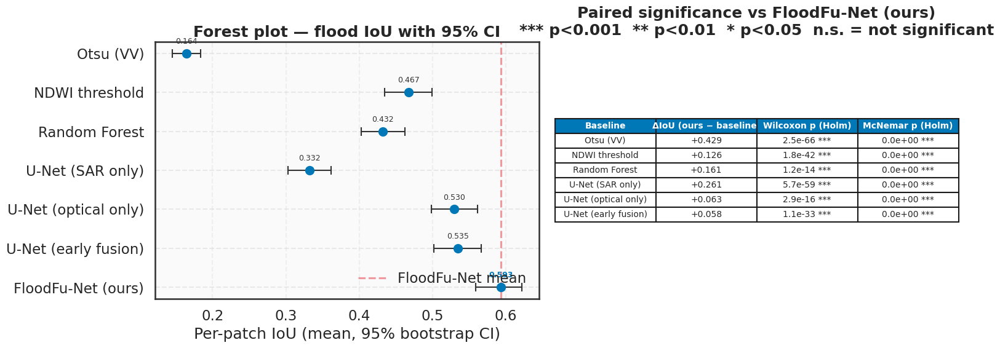

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

order = METHOD_ORDER
means, lows, highs = [], [], []
for m in order:
    mu, lo, hi = bootstrap_ci(per_patch[m])
    means.append(mu); lows.append(mu - lo); highs.append(hi - mu)

y = np.arange(len(order))[::-1]
ax[0].errorbar(means, y, xerr=[lows, highs], fmt='o',
                markersize=10, capsize=5, capthick=1.5, elinewidth=1.5,
                color='#0077b6', ecolor='#333')
for yi, m, mu in zip(y, order, means):
    hi = m == REF
    ax[0].text(mu, yi + 0.25, f'{mu:.3f}', ha='center', fontsize=9,
                color='#0077b6' if hi else '#333',
                fontweight='bold' if hi else 'normal')
ax[0].set_yticks(y); ax[0].set_yticklabels(order)
ax[0].axvline(means[order.index(REF)], color='#e63946', ls='--', alpha=0.5, label='FloodFu-Net mean')
ax[0].set_xlabel('Per-patch IoU (mean, 95% bootstrap CI)')
ax[0].set_title('Forest plot — flood IoU with 95% CI')
ax[0].legend(frameon=False, loc='lower right')
ax[0].grid(True, axis='x', ls='--', alpha=0.4)

ax[1].axis('off')
tbl = stats_df[['method', 'delta', 'wilcoxon_p_adj', 'mcnemar_p_adj']].copy()
tbl['delta']          = tbl['delta'].map(lambda v: f'{v:+.3f}')
def _stars(p): return ' ***' if p < 0.001 else ' **' if p < 0.01 else ' *' if p < 0.05 else ' n.s.'
tbl['wilcoxon_p_adj'] = tbl['wilcoxon_p_adj'].map(lambda p: f'{p:.1e}' + _stars(p))
tbl['mcnemar_p_adj']  = tbl['mcnemar_p_adj'].map(lambda p: f'{p:.1e}' + _stars(p))
tbl.columns = ['Baseline', 'ΔIoU (ours − baseline)', 'Wilcoxon p (Holm)', 'McNemar p (Holm)']
tt = ax[1].table(cellText=tbl.values, colLabels=tbl.columns, loc='center', cellLoc='center')
tt.auto_set_font_size(False); tt.set_fontsize(10); tt.scale(1.05, 1.6)
for j in range(len(tbl.columns)):
    tt[0, j].set_facecolor('#0077b6'); tt[0, j].set_text_props(color='white', weight='bold')
ax[1].set_title('Paired significance vs FloodFu-Net (ours)\n*** p<0.001  ** p<0.01  * p<0.05  n.s. = not significant', pad=8)

plt.tight_layout()
plt.savefig(DIRS['figures'] / 'stage10_significance.png', dpi=170, bbox_inches='tight')
plt.show()

## Stage 11 — Publication-quality composite figure

One large figure suitable for a paper's main results section: metric table, ROC, radar, per-event heatmap, ablation, boundary quality, efficiency scatter, and a qualitative row.

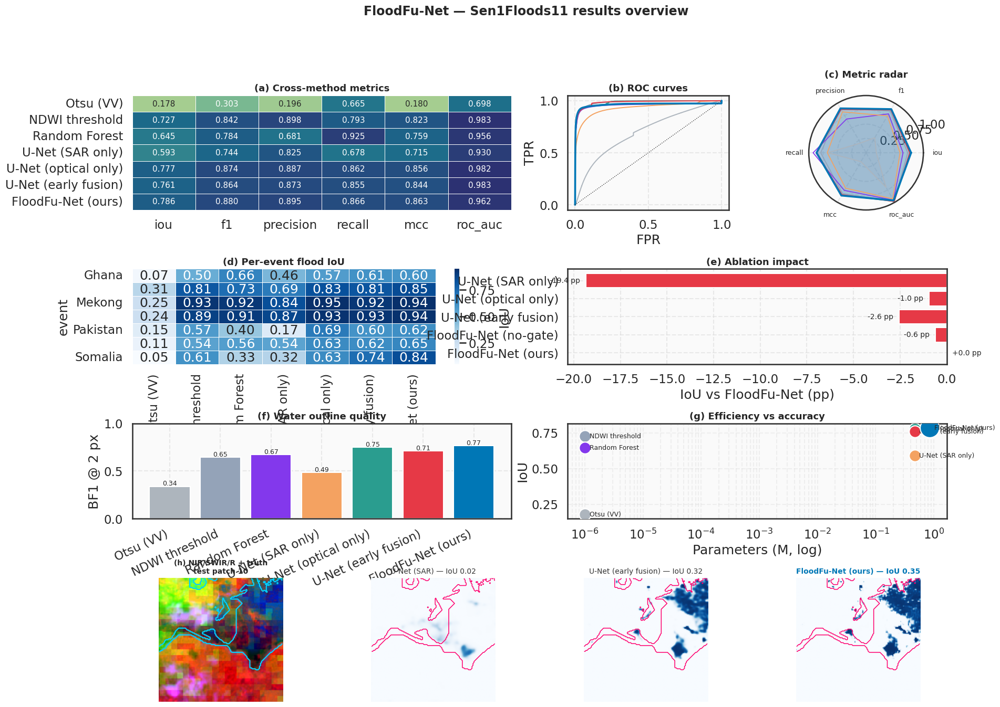

Composite saved as PNG and PDF for the paper.


In [ ]:
import matplotlib.gridspec as ggs
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(20, 15))
outer = ggs.GridSpec(4, 4, figure=fig,
                     height_ratios=[1.2, 1.0, 1.0, 1.3],
                     hspace=0.55, wspace=0.35)

# (a) metric table
axA1 = fig.add_subplot(outer[0, :2])
tbl_cols = ['iou', 'f1', 'precision', 'recall', 'mcc', 'roc_auc']
tbl = pd.DataFrame({m: {k: all_results[m][k] for k in tbl_cols}
                     for m in METHOD_ORDER}).T
sns.heatmap(tbl, annot=True, fmt='.3f', cmap='crest',
            cbar=False, linewidths=.4, ax=axA1,
            annot_kws={'fontsize': 11})
axA1.set_title('(a) Cross-method metrics', fontsize=13)

# (b) ROC
axA2 = fig.add_subplot(outer[0, 2])
for m in METHOD_ORDER:
    yt = Yte.ravel()[Vte.ravel() == 1]
    yp = preds_by_method[m].ravel()[Vte.ravel() == 1]
    fpr, tpr, _ = roc_curve(yt, yp)
    lw = 2.6 if m == 'FloodFu-Net (ours)' else 1.4
    axA2.plot(fpr, tpr, color=METHOD_COLORS[m], lw=lw)
axA2.plot([0, 1], [0, 1], ls=':', color='#333', lw=1)
axA2.set_xlabel('FPR'); axA2.set_ylabel('TPR')
axA2.set_title('(b) ROC curves', fontsize=13)

# (c) Radar
axA3 = fig.add_subplot(outer[0, 3], projection='polar')
for m in METHOD_ORDER:
    vals = [all_results[m][k] for k in radar_metrics] + [all_results[m][radar_metrics[0]]]
    lw = 2.6 if m == 'FloodFu-Net (ours)' else 1.2
    al = 0.30 if m == 'FloodFu-Net (ours)' else 0.05
    axA3.plot(angles, vals, color=METHOD_COLORS[m], lw=lw)
    axA3.fill(angles, vals, color=METHOD_COLORS[m], alpha=al)
axA3.set_xticks(angles[:-1]); axA3.set_xticklabels(radar_metrics, fontsize=9)
axA3.set_ylim(0, 1); axA3.set_title('(c) Metric radar', fontsize=13, y=1.12)

# (d) per-event heatmap
axB1 = fig.add_subplot(outer[1, :2])
if per_region_df.size > 0:
    sns.heatmap(per_region_df, annot=True, fmt='.2f', cmap='Blues',
                cbar_kws={'label': 'IoU'}, ax=axB1, linewidths=.4)
axB1.set_title('(d) Per-event flood IoU', fontsize=13)
axB1.set_xlabel(''); axB1.set_ylabel('event')

# (e) ablation
axB2 = fig.add_subplot(outer[1, 2:])
ref = all_results['FloodFu-Net (ours)']['iou']
deltas = [(all_results[m]['iou'] - ref) * 100 for m in ablate_set]
axB2.barh(ablate_set[::-1], deltas[::-1],
           color=['#e63946' if d < 0 else '#0077b6' for d in deltas[::-1]],
           edgecolor='white')
for i, d in enumerate(deltas[::-1]):
    axB2.text(d + (0.3 if d >= 0 else -0.3), i, f'{d:+.1f} pp',
               va='center', ha='left' if d >= 0 else 'right', fontsize=10)
axB2.axvline(0, color='#333', lw=0.8)
axB2.set_xlabel('IoU vs FloodFu-Net (pp)')
axB2.set_title('(e) Ablation impact', fontsize=13)

# (f) boundary F1
axC1 = fig.add_subplot(outer[2, :2])
bf1_vals = [boundary[m]['BF1@2px'] for m in METHOD_ORDER]
bars = axC1.bar(range(len(METHOD_ORDER)), bf1_vals,
                 color=[METHOD_COLORS[m] for m in METHOD_ORDER],
                 edgecolor='white')
for b, v in zip(bars, bf1_vals):
    axC1.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.2f}',
               ha='center', fontsize=9)
axC1.set_xticks(range(len(METHOD_ORDER)))
axC1.set_xticklabels(METHOD_ORDER, rotation=25, ha='right')
axC1.set_ylim(0, 1); axC1.set_ylabel('BF1 @ 2 px')
axC1.set_title('(f) Water outline quality', fontsize=13)

# (g) efficiency scatter
axC2 = fig.add_subplot(outer[2, 2:])
for m in METHOD_ORDER:
    p = max(all_results[m]['params'], 1) / 1e6
    iou = all_results[m]['iou']
    size = 700 if m == 'FloodFu-Net (ours)' else 260
    axC2.scatter(p, iou, s=size, color=METHOD_COLORS[m],
                  edgecolor='white', linewidths=1.5, zorder=3)
    axC2.text(p * 1.2, iou, m, fontsize=9, va='center')
axC2.set_xscale('log')
axC2.set_xlabel('Parameters (M, log)')
axC2.set_ylabel('IoU')
axC2.set_title('(g) Efficiency vs accuracy', fontsize=13)
axC2.grid(True, which='both', ls='--', alpha=0.4)

# (h) qualitative row
mean_flood_te2 = Yte.mean(axis=(1, 2))
cand2 = np.where((mean_flood_te2 > 0.20) & (mean_flood_te2 < 0.55))[0]
if len(cand2) < 1: cand2 = np.argsort(-mean_flood_te2)[:1]
demo_idx = int(cand2[0])

sub = ggs.GridSpecFromSubplotSpec(1, 4, subplot_spec=outer[3, :])
col_defs = [('NIR/SWIR/R + truth', None),
            ('U-Net (SAR)',        'U-Net (SAR only)'),
            ('U-Net (early fusion)', 'U-Net (early fusion)'),
            ('FloodFu-Net (ours)',  'FloodFu-Net (ours)')]

for c, (title, m) in enumerate(col_defs):
    ax_ = fig.add_subplot(sub[0, c])
    if m is None:
        bg = np.stack([stretch_ch(Xte[demo_idx, CHANNEL_NAMES.index('B_NIR')]),
                       stretch_ch(Xte[demo_idx, CHANNEL_NAMES.index('B_SWIR')]),
                       stretch_ch(Xte[demo_idx, CHANNEL_NAMES.index('B_red')])], axis=-1)
        ax_.imshow(bg)
        ax_.contour(Yte[demo_idx] == 1, colors=['#00d0ff'], linewidths=1.6)
        ax_.set_title(f'(h) {title}\ntest patch {demo_idx}', fontsize=10)
    else:
        pm = preds_by_method[m][demo_idx]
        ax_.imshow(pm, cmap='Blues', vmin=0, vmax=1)
        ax_.contour(Yte[demo_idx] == 1, colors=['#ff006e'], linewidths=1.1)
        vm = Vte[demo_idx] == 1
        iou_p = jaccard_score((Yte[demo_idx][vm] == 1).ravel(),
                              (pm[vm] > 0.5).astype('uint8').ravel(),
                              pos_label=1, zero_division=0)
        highlight = m == 'FloodFu-Net (ours)'
        ax_.set_title(f'{title} — IoU {iou_p:.2f}',
                       fontsize=10,
                       color='#0077b6' if highlight else '#333',
                       fontweight='bold' if highlight else 'normal')
    ax_.axis('off')

fig.suptitle('FloodFu-Net — Sen1Floods11 results overview',
              fontsize=17, y=0.995, fontweight='bold')

plt.savefig(DIRS['figures'] / 'stage11_composite.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.savefig(DIRS['figures'] / 'stage11_composite.pdf',
            bbox_inches='tight', facecolor='white')
plt.show()
print('Composite saved as PNG and PDF for the paper.')

## Stage 12 — Manifest and reproducibility bundle

In [ ]:
# Defensive manifest — writes whatever is available so far.
# Missing names from Stages 8-11 are treated as empty and reported so.
def _safe(name, default):
    return globals().get(name, default)

def _load_json_if(path):
    p = Path(path)
    if p.exists():
        try:
            return json.loads(p.read_text())
        except Exception:
            return None
    return None

methods            = _safe('METHOD_ORDER', [])
all_results_local  = _safe('all_results', _load_json_if(CKPT / 'stage8_all_results.json') or {})
boundary_local     = _safe('boundary',    _load_json_if(CKPT / 'stage10_boundary.json') or {})
per_region_local   = _safe('per_region',  {})

if not methods and all_results_local:
    preferred = ['Otsu (VV)', 'NDWI threshold', 'Random Forest',
                 'U-Net (SAR only)', 'U-Net (optical only)',
                 'U-Net (early fusion)', 'FloodFu-Net (no-gate)',
                 'FloodFu-Net (ours)']
    methods = [m for m in preferred if m in all_results_local]

metric_keys = ['iou', 'f1', 'precision', 'recall', 'mcc', 'roc_auc']

manifest = {
    'root'          : str(ROOT),
    'dataset'       : 'Sen1Floods11 (Hand-Labeled)',
    'source'        : BASE,
    'per_split_cap' : MAX_PER_SPLIT,
    'stage_5_metrics': _safe('metrics', _load_json_if(CKPT / 'stage6_metrics.json') or {}),
    'methods'       : methods,
    'headline_metrics_by_method': {
        m: {k: round(all_results_local[m][k], 4)
            for k in metric_keys if k in all_results_local.get(m, {})}
        for m in methods
    },
    'boundary_quality' : boundary_local,
    'per_event'        : per_region_local,
    'checkpoints'      : {p.name: str(p) for p in CKPT.iterdir()},
    'figures'          : sorted(str(p) for p in DIRS['figures'].glob('*.png')),
    'composite_pdf'    : str(DIRS['figures'] / 'stage11_composite.pdf')
                          if (DIRS['figures'] / 'stage11_composite.pdf').exists() else None,
    'comparison_csv'   : str(CKPT / 'stage8_comparison_table.csv')
                          if (CKPT / 'stage8_comparison_table.csv').exists() else None,
    'per_region_csv'   : str(CKPT / 'stage10_per_region.csv')
                          if (CKPT / 'stage10_per_region.csv').exists() else None,
    'saved_at'         : dt.datetime.utcnow().isoformat(),
}

if not methods:
    print('NOTE: baseline stages 8-11 not yet run in this session.')
    print('      Run those cells first to populate the full comparison manifest.')

(ROOT / 'run_manifest.json').write_text(json.dumps(manifest, indent=2, default=str))
print(json.dumps(manifest, indent=2, default=str))

/tmp/ipykernel_525/2461733563.py:51: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



{
  "root": "/content/drive/MyDrive/FloodFuNet",
  "dataset": "Sen1Floods11 (Hand-Labeled)",
  "source": "https://storage.googleapis.com/sen1floods11/v1.1",
  "per_split_cap": {
    "train": 300,
    "val": 60,
    "test": 60
  },
  "stage_5_metrics": {
    "iou_flood": 0.7861435568122759,
    "f1_flood": 0.880269174125403,
    "precision": 0.8953193314351747,
    "recall": 0.8657166328668043,
    "mcc": 0.8633049317095018,
    "overall_acc": 0.9700294156792322
  },
  "methods": [
    "Otsu (VV)",
    "NDWI threshold",
    "Random Forest",
    "U-Net (SAR only)",
    "U-Net (optical only)",
    "U-Net (early fusion)",
    "FloodFu-Net (ours)"
  ],
  "headline_metrics_by_method": {
    "Otsu (VV)": {
      "iou": 0.1785,
      "f1": 0.3029,
      "precision": 0.196,
      "recall": 0.6654,
      "mcc": 0.18,
      "roc_auc": 0.6981
    },
    "NDWI threshold": {
      "iou": 0.7273,
      "f1": 0.8421,
      "precision": 0.8983,
      "recall": 0.7925,
      "mcc": 0.8228,
      "roc_au